In [959]:
# Setup Cell: import all dependencies and define global constants

import marimo as mo
import os
import shutil
import sys
from pathlib import Path

# Make imports work from either the repo root or the notebook folder.
_CWD = Path.cwd().resolve()
_PROJECT_ROOT = next(
    (p for p in [_CWD, *_CWD.parents] if (p / 'Tutorial_Notebooks').exists()),
    _CWD,
)
_NOTEBOOK_UTILS = _PROJECT_ROOT / 'Tutorial_Notebooks' / 'Notebook_Utils'
for _path in (_PROJECT_ROOT, _NOTEBOOK_UTILS):
    if _path.exists() and str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

# Qiskit's gate-map drawing needs the Graphviz `dot` executable.
for _bin_dir in ('/opt/homebrew/bin', '/usr/local/bin'):
    if Path(_bin_dir).exists() and _bin_dir not in os.environ['PATH'].split(os.pathsep):
        os.environ['PATH'] = f"{_bin_dir}{os.pathsep}{os.environ['PATH']}"
GRAPHVIZ_DOT = shutil.which('dot')
GRAPHVIZ_INSTALL_HINT = (
    None
    if GRAPHVIZ_DOT
    else 'Graphviz command-line tools are missing. Install them with `brew install graphviz` and restart the kernel.'
)


# standard/numerical
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Arc
import networkx as nx
import pandas as pd

# qiskit
# we avoid the pattern `from qiskit.submodule import Class` to make it clear in each cell where each function/class comes from
import qiskit
import qiskit.visualization
import qiskit_ibm_runtime
import qiskit_aer
from qiskit.exceptions import MissingOptionalLibraryError
if hasattr(qiskit.utils.optionals.HAS_GRAPHVIZ, '_bool'):
    qiskit.utils.optionals.HAS_GRAPHVIZ._bool = None

# bosonic
import bosonic_sdk
from bosonic_converters import CircuitConverters # sufficiently self-explanatory
from distribution_tutorial_utils import (
    SherbrookeLikeBackendFactory,
    apply_tts_model,
    bosonic_metric_summary,
    brickwork_circuit,
    chain_circuit,
    collect_compile_rows,
    extended_gate_count_prediction,
    ibm_heavy_hex_metric_summary,
    load_compile_cache,
    plot_benchmark_grid,
    plot_benchmark_metric,
    plot_measured_and_extrapolated_metric,
    save_compile_cache,
    sorted_series_groups,
    transpile_metric_summary,
    unique_int_linspace,
    unique_int_logspace,
)

# filter warnings
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
)

# config constants
VERIFY_CFG = {
    'N_LIST': range(3, 21), # circuit sizes to sweep over
    'SHOTS': 2048, # number of times to simulate each circuit
    'SEED': 1234, # RNG seed to ensure reproducibility
}

SCALING_CFG = {
    'N_LIST': range(3, 128),
    'QUBITS_PER_TRAP': 32,
}

TTS_CFG = {
    'SHOTS': 1024,
    'N_LIST': range(5, 126, 5),
    'QUBITS_PER_TRAP': 128,
}

IBM_PLOT_COLOR = '#1f77b4'
BOSONIC_PLOT_COLOR = '#d62728'
BACKEND_PLOT_STYLES = {
    'IBM': {'color': IBM_PLOT_COLOR},
    'Bosonic': {'color': BOSONIC_PLOT_COLOR},
}


# Introduction

Interest in quantum computing has been rising in recent years because of its potential to tackle classically intractable problems in areas like chemistry, optimization, and materials design. This all sounds amazing but realizing this potential has proven itself to be challenging. This is because achieving these killer appilcations requires scaling devices to much larger qubit numbers and higher fidelities than they are today. Current devices have monolithic architectures, where all qubits live on a single tightly integrated chip. This approach faces severe challenges as they grow: control wiring, crosstalk, noise, and fabrication complexity all make it increasingly difficult to simply “build a bigger processor with more qubits”. Distributed quantum computing offers an alternative path to quantum utility by stitching together many smaller quantum modules into a larger effective processor, connected via entanglement. However, this comes with a crucial tradeoff: remote or cross‑module gates are far more expensive and error-prone than local operations, and their cost grows with the amount of communication required. Naturally, one may ask themselves: given these communication costs, how do monolithic and distributed approaches compare as we scale to the problem sizes we'd need to realize killer applications?


The goal of the notebook is to explore this question. To keep scaling behavior consistent, we choose an easy scalable circuit family, that is the circuits that produce GHZ states. A GHZ state is simply $\frac{1}{\sqrt{2^{n}}}|00...0_{n}> + |11...1_{n}>$ which can be achievede by starting with a hadamard gate on qubit one and a CNOT on additional qubits. 

The notebook is split into three main sections:

1. **Generating GHZ circuits** – We use GHZ circuits because they are simple and easy to follow for each additional qubit we add one CNOT gate. This simplicity lets us focus on differences between monolithic and distributed approaches without having to worry about other effects of the circuit as we scale.

2. **Validation** – To explore scaling behaviours we take the same logical circuit and compile it into a monolithic circuit to be executed on an IBM system and a distributed circuit to be executed on a Bosonic system. Each compliled circuit is then simulated using Qiskit Aer. In this step we validate correctness in our simulators by sampling GHZ circuits and checking expected outputs.

3. **Exploration** – After validation, we study scaling from two perspectives:
   - Circuit metrics: How do metrics like depth, gate counts, and related compiled-circuit characteristics scale as we increase circuit sizes? 
   - Hardware metrics: We use an execution-time model that includes practical hardware considerations to estimate time to solution as we scale circuit sizes 

Lastly, we will use the following notation:

- *$n$*: number of qubits
- "remote" or "cross-module" gates: two-qubit interactions whose endpoints lie in different modules (two-qubit gates between qubits in different modules).

# GHZ Circuit Generator

Now that we have installed all dependencies and given an overview of the notebook content, we can start building our test circuit. A Greenberger-Horne-Zeilinger (GHZ) state on $n$ qubits is defined as:

$$
\lvert \mathrm{GHZ}_n \rangle
=
\frac{1}{\sqrt{2}}
\left(
\lvert 00\ldots 0_n \rangle
+
\lvert 11\ldots 1_n \rangle
\right)
=
\frac{1}{\sqrt{2}}
\left(
\lvert 0 \rangle^{\otimes n}
+
\lvert 1 \rangle^{\otimes n}
\right).
$$

After measuring all qubits in the computational basis, the ideal outcome distribution is:

$$
\Pr(x) = \begin{cases}
\frac{1}{2}, & x = 0^n \text{ or } 1^n \\
0, & \text{otherwise}
\end{cases}
$$

In other words we expect to measure a 0 exactly one half of the time and a 1 the other half. The circuit that generates this state is simple and involves two steps:

1. Apply $H$ to qubit $0$.
2. Apply $\mathrm{CX}(0 \to i)$ for $i = 1, \dots, n-1$.

In [960]:
def ghz_circuit(n: int, measure: bool = True) -> qiskit.QuantumCircuit:
    """Create a GHZ state circuit on n qubits."""
    qc = qiskit.QuantumCircuit(n, n)
    # qc = QuantumCircuit(n, n)
    qc.h(0)
    for i in range(1, n):
        qc.cx(0, i)
    if measure:
        qc.measure(range(n), range(n))
    return qc

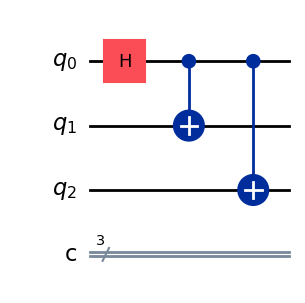

In [961]:
ghz_circuit(3, measure=False).draw("mpl")

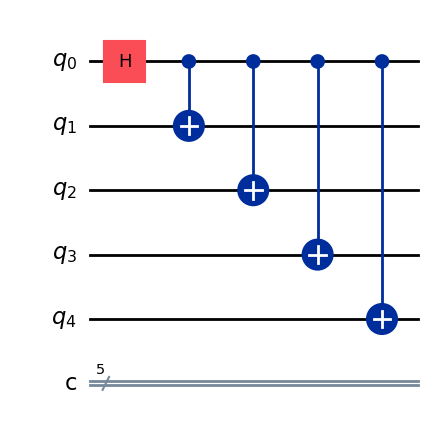

In [962]:
ghz_circuit(5, measure=False).draw("mpl")

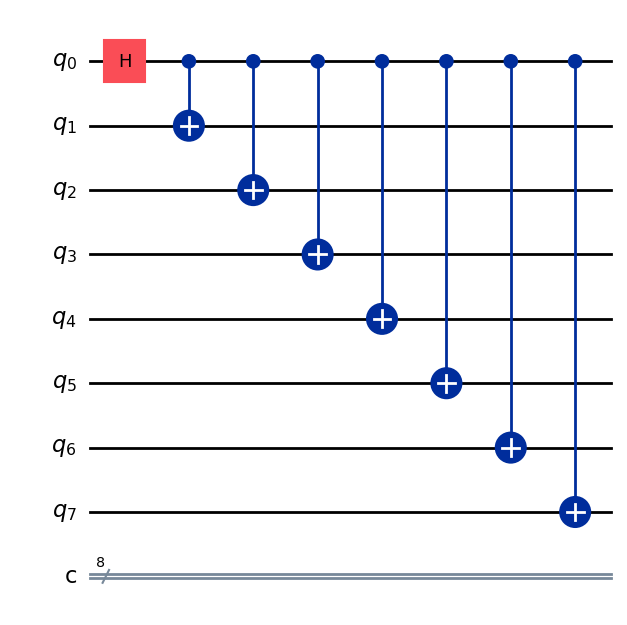

In [963]:
ghz_circuit(8, measure=False).draw("mpl")

# Validating the Circuits

Now that we have defined our circuit, the next step is to verify their behavior by confirming that simulations return the expected measurement distribution.

The simulators return measurement `counts` over `SHOTS` samples. For an ideal GHZ state, we expect roughly an equal amount of $0^n$ and $1^n$ measurements:

$$
\texttt{counts}[0^n] \approx \frac{\texttt{SHOTS}}{2},
\qquad
\texttt{counts}[1^n] \approx \frac{\texttt{SHOTS}}{2},
$$

and all other bitstrings should never be measured.

We use these counts to define a simple fidelity proxy to ensure that we are measuring what we expect:

$$
\widehat{F}_{\mathrm{GHZ}}(n)
=
\frac{\texttt{counts}[0^n] + \texttt{counts}[1^n]}{\texttt{SHOTS}}.
$$

- $\widehat{F}_{\mathrm{GHZ}}(n) = 1$ means that we measured nothing but the expected bitstrings and our simulators are working as intended.
- $\widehat{F}_{\mathrm{GHZ}}(n) < 1$ means that we measured at least one incorrect bitstring. Without any noise models this means that our simulators are not working as expected.

In the following section, for each circuit size $n$, we:

- Simulate the circuit
- Collect measurement counts
- Compute and plot the proxy scores

We start by defining the parameters of our circuit sweep:

In [964]:
VERIFY_CFG

{'N_LIST': range(3, 21), 'SHOTS': 2048, 'SEED': 1234}

## Monolithic Circuit Simulation

To simulate monolithic circuits, we will use Qiskit's Aer simulator transpiled to IBM's [`FakeSherbrooke`](https://quantum.cloud.ibm.com/docs/en/api/qiskit-ibm-runtime/fake-provider-fake-sherbrooke) backend, a (non-existent) 127-qubit QPU.

In [965]:
FAKE_IBM_BACKEND = qiskit_ibm_runtime.fake_provider.FakeSherbrooke()

We can use Qiskit to visualize the qubit layout of the processor:

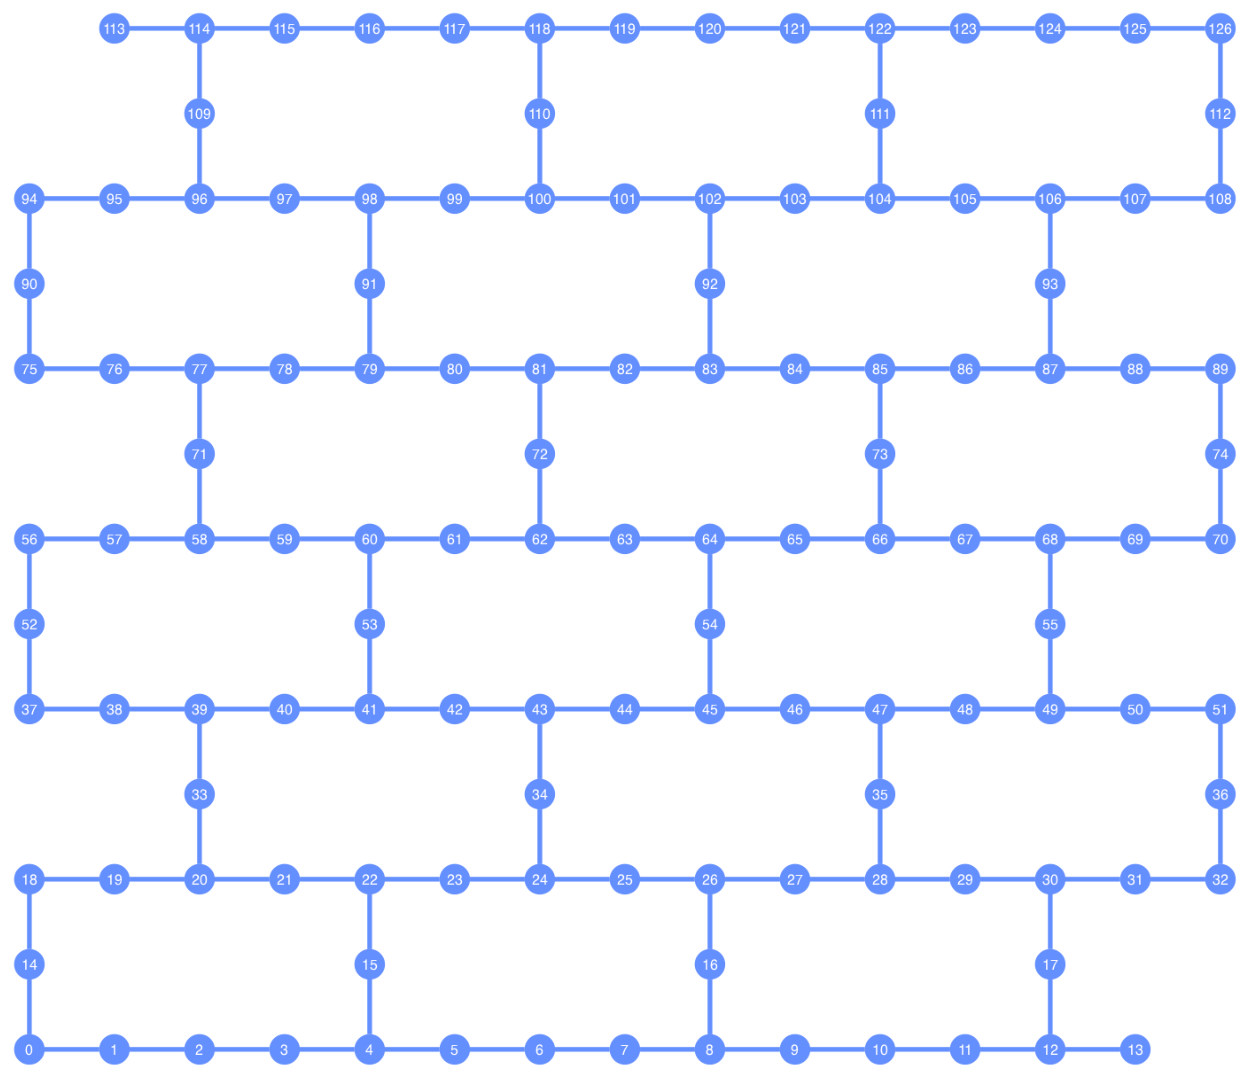

In [966]:
qiskit.visualization.plot_gate_map(FAKE_IBM_BACKEND) if qiskit.utils.optionals.HAS_GRAPHVIZ else GRAPHVIZ_INSTALL_HINT

Notice how the qubits are laid out. All of the CNOT gates involved in our GHZ circuit can't happen directly because each qubit is touching at most three neighboring qubits. This means lots of SWAP gates, with the number of SWAPs increasing as more distant qubits need to be entangled.

Let's start with the basics of running a circuit through the IBM simulator. First, we'll define a GHZ circuit with only $n=3$ qubits:

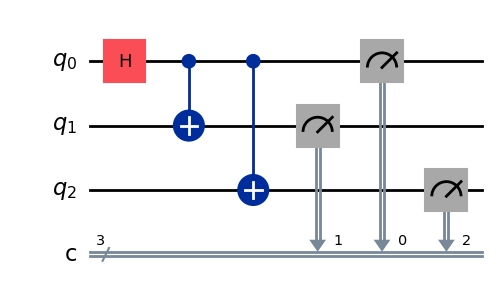

In [967]:
ibm_circ3 = ghz_circuit(3)
ibm_circ3.draw('mpl')

This is called the *logical circuit* and has only a few gate layers.

In [968]:
ibm_circ3.depth()

4

Next, we *transpile* the circuit to the hardware backend, replacing the logical gates with equivalent operations that are allowed on the hardware, restricted by:

1. **Native gate set** – set of unitaries the hardware can physically execute
2. **Connectivity** – entangling gates can only be performed on qubits that are adjacent in the hardware gate map

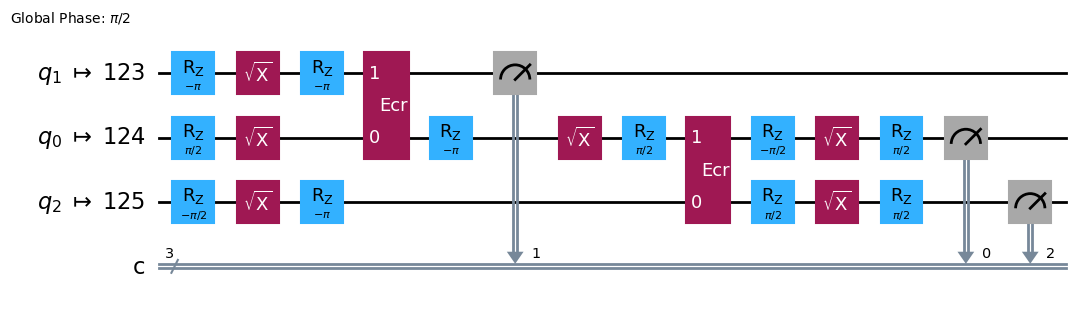

In [969]:
ibm_transpiled3 = qiskit.transpile(ibm_circ3, backend=FAKE_IBM_BACKEND)
ibm_transpiled3.draw('mpl')

Notice how we no longer have H and CNOT gates; they've been replaced with the gates that can actually be performed by the hardware, and you'll notice that the first and third qubits are never directly entangled (because they aren't physically connected on the QPU). Transpilation will typically increase the gate depth because logical gates have to be broken down into multiple physical gates to actually run on hardware.

In [970]:
ibm_transpiled3.depth()

12

Now that we have a circuit that can run on "real" hardware, let's simulate it!

In [971]:
ibm_result3 = qiskit_aer.AerSimulator().run(ibm_transpiled3, shots=VERIFY_CFG['SHOTS']).result()
ibm_result3.to_dict()

{'backend_name': 'aer_simulator',
 'backend_version': '0.17.2',
 'date': '2026-08-11T23:25:27.199287',
 'header': None,
 'job_id': 'ed48a25e-544a-4ff4-8057-7ac5b878d53c',
 'status': 'COMPLETED',
 'success': True,
 'results': [{'shots': 2048,
   'success': True,
   'data': {'counts': {'0x0': 1041, '0x7': 1007}},
   'meas_level': <MeasLevel.CLASSIFIED: 2>,
   'header': {'creg_sizes': [['c', 3]],
    'global_phase': 1.570796326794901,
    'memory_slots': 3,
    'n_qubits': 127,
    'name': 'circuit-64959',
    'qreg_sizes': [['q', 127]],
    'metadata': {}},
   'status': 'DONE',
   'seed_simulator': 2740598228,
   'metadata': {'num_bind_params': 1,
    'runtime_parameter_bind': False,
    'parallel_state_update': 10,
    'parallel_shots': 1,
    'sample_measure_time': 0.001192792,
    'noise': 'ideal',
    'batched_shots_optimization': False,
    'remapped_qubits': True,
    'active_input_qubits': [123, 124, 125],
    'device': 'CPU',
    'time_taken': 0.001617541,
    'measure_sampling':

You can see there's a lot of information, but we only care about the measurement counts, which we can access with the `get_counts()` method:

In [972]:
ibm_result3.get_counts()

{'000': 1041, '111': 1007}

This is what we expected: only the outcomes `000` and `111` are measured, meaning we (most likely) successfully created a GHZ state!

Let's go ahead and compute the proxy measure we came up with earlier:

$$
\widehat{F}_{\mathrm{GHZ}}(n)
=
\frac{\texttt{counts}[0^n] + \texttt{counts}[1^n]}{\texttt{SHOTS}}.
$$

In [973]:
def ghz_fidelity_proxy(counts):
    n = min(len(k) for k in counts.keys()) # compute n using length of measured bitstrings
    shots = sum(counts.values()) # sum measurement counts over all bitstrings
    return (counts.get('0' * n, 0) + counts.get('1' * n, 0)) / shots

In [974]:
ghz_fidelity_proxy(ibm_result3.get_counts())

1.0

Now that we know how the simulator behaves and what data we need, let's write a function to handle the other cases we want to study:

In [975]:
def verify_ghz_ibm(n, shots=VERIFY_CFG['SHOTS']):
    circ = qiskit.transpile(ghz_circuit(n), backend=FAKE_IBM_BACKEND)
    counts = qiskit_aer.AerSimulator().run(circ, shots=shots).result().get_counts()
    data = {
        'backend': 'IBM',
        'n': n,
        'depth': circ.depth(),
        'count0': counts.get('0' * n, 0),
        'count1': counts.get('1' * n, 0),
    }
    return data

In [976]:
ibm_data = [verify_ghz_ibm(n) for n in VERIFY_CFG['N_LIST']]
pd.DataFrame(ibm_data)

,backend,n,depth,count0,count1
0,IBM,3,12,1046,1002
1,IBM,4,18,1035,1013
2,IBM,5,27,1017,1031
3,IBM,6,45,1028,1020
4,IBM,7,50,1042,1006
...,...,...,...,...,...
13,IBM,16,134,1018,1030
14,IBM,17,187,1044,1004
15,IBM,18,142,1065,983
16,IBM,19,156,1051,997


## Distributed Circuit Simulation

Next, we simulate the same circuit distributed over multiple modules using the [Bosonic SDK]([https://](https://github.com/dqc-community/dqcomp)) to transpile logical circuits to the qubit layout and instruction set of our hardware architecture.

Bosonic's architecture is a **distributed trapped-ion quantum computer with photonic interconnects**. This sounds like a mouthful so lets break it down step by step, starting with the fact that Bosonic has a **distributed architecture**. This neans that instead of building one very large quantum processor, the system is built from many smaller, identical quantum processing units (QPUs); each smaller unit is refered to as a _module_. Each module is able to act independently and stores local qubits, runs local quantum gates, and communicates with other modules to perform remote gates.

Second, Bosonic's architecture is based on **trapped ions** – ions held in place by a magnetic field and used to encode a qubit. A qubit state is given by the ion's energy levels, and we perform entangling gates by interacting with other ions. Inside each module, ions are held in a static chain and have **all-to-all connectivity**, meaning any two qubits in the same chain can entangle directly with each other (i.e., we can perform **transversal gates** ). When we transpile a logical circuit down into physical instructions on our hardware, we do not need to use SWAP chains (or physical shuttling operations!) to entangle two qubits that are not physical neighbors.

Finally, our architecture uses **photonic interconnects** to connect modules to each other. We use optical cavities (a small pair of mirrors) to improve the way that ions emit and absorb photons. Ions emit photons when their energy level increases, and they absorb photons when it drops. Our architecture uses this natural property of ions to allow for communication between modules, and we call the creation of a link via this process a **remote link**. Remote links by themselves aren't enough to perform remote gates; they generate a **Bell pair** of entangled qubits (or **ebits**) in separate traps, and we can then perform local operations on the ebits to complete the intended logical operation.

Because of this two-step remote gate procedure, it is conceptually simpler (but not strictly necessary) to treat each physical qubit as either a **data qubit** used for local operations and participation in the logical circuit or a **communication qubit** dedicated to generating Bell pairs for cross-module entanglement. Here's a diagram of an architecture consisting of modules (each with a data qubit register and communication qubit register) linked by an optical network.

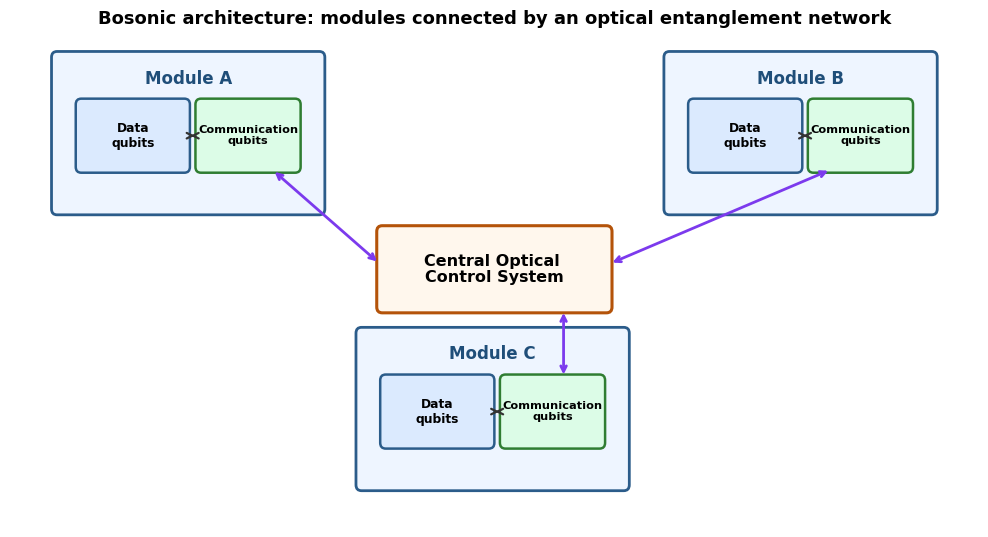

In [977]:
def _draw_bosonic_architecture_diagram():
    # System-level Bosonic architecture diagram
    fig, ax = plt.subplots(figsize=(12.5, 6.6))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 7)
    ax.axis('off')

    def box(x, y, w, h, label, fc='#f7f7f7', ec='#333333', lw=1.8, size=10, weight='normal'):
        patch = FancyBboxPatch(
            (x, y), w, h,
            boxstyle='round,pad=0.05,rounding_size=0.08',
            facecolor=fc,
            edgecolor=ec,
            linewidth=lw,
        )
        ax.add_patch(patch)
        ax.text(
            x + w / 2,
            y + h / 2,
            label,
            ha='center',
            va='center',
            fontsize=size,
            weight=weight,
            linespacing=1.15,
        )
        return patch

    def module(x, y, name):
        box(x, y, 3.85, 2.15, '', fc='#eef5ff', ec='#2b5c8a', lw=2.0)
        ax.text(
            x + 1.925,
            y + 1.83,
            name,
            ha='center',
            va='center',
            fontsize=12,
            weight='bold',
            color='#1f4e79',
        )
        box(x + 0.35, y + 0.58, 1.55, 0.92, 'Data\nqubits', fc='#dbeafe', ec='#2b5c8a', size=8.8, weight='bold')
        box(x + 2.08, y + 0.58, 1.42, 0.92, 'Communication\nqubits', fc='#dcfce7', ec='#2f7d32', size=8.2, weight='bold')
        ax.annotate(
            '',
            xy=(x + 2.08, y + 1.04),
            xytext=(x + 1.90, y + 1.04),
            arrowprops=dict(arrowstyle='<->', lw=1.6, color='#333333', shrinkA=3, shrinkB=3),
        )
        return (x + 2.79, y + 1.04)

    module(0.65, 4.35, 'Module A')
    module(9.5, 4.35, 'Module B')
    module(5.05, 0.55, 'Module C')

    # Anchor arrows on the edges of the communication boxes so they do not cross the text.
    comm_a_edge = (3.78, 4.93)
    comm_b_edge = (11.88, 4.93)
    comm_c_edge = (7.00, 2.70)

    switch_center = (7.0, 3.55)
    box(5.35, 3.0, 3.3, 1.1, 'Central Optical \nControl System', fc='#fff7ed', ec='#b45309', lw=2.2, size=11.5, weight='bold')

    links = [
        (comm_a_edge, (5.35, 3.62)),
        (comm_b_edge, (8.65, 3.62)),
    ]
    for start, end in links:
        ax.annotate(
            '',
            xy=end,
            xytext=start,
            arrowprops=dict(arrowstyle='<->', lw=2.0, color='#7c3aed', shrinkA=3, shrinkB=3),
        )

    # Draw the Module C connection manually so it stays visible and avoids labels.
    ax.annotate(
        '',
        xy=(8.00, 2.1),
        xytext=(8.00, 2.95),
        arrowprops=dict(arrowstyle='<->', lw=2.0, color='#7c3aed', shrinkA=0, shrinkB=0),
    )

    ax.text(
        7.0,
        7,
        'Bosonic architecture: modules connected by an optical entanglement network',
        ha='center',
        va='center',
        fontsize=13,
        weight='bold',
    )
    plt.show()
_draw_bosonic_architecture_diagram()

Recall that we specified the monolithic backend's connectivity and native gate set (using the `FakeSherbrooke` backend). What do we need to know about a distributed backend using the architecture we've just described? Since qubit connectivity _within_ a module is all-to-all, and connectivity _across_ modules is also all-to-all, the only thing we need to know is:

1. The number of modules (`nodes`)
2. The number of qubits in each module (`qubits_per_node`)
3. The strategy for assigning communication qubits and establishing remote links (a `Distributor` object)

Because Qiskit doesn't (yet!) have the machinery to handle distribution algorithms, we have to translate circuits out of Qiskit into our own internal representation, transpile them, and then convert them back.

In [978]:
def compile_bosonic_circuit(circuit, n, modules, distributor):
    """Distribute a Qiskit circuit across Bosonic modules and return a Qiskit circuit."""
    distributed = distributor.distribute(
        CircuitConverters.from_qiskit(circuit),
        nodes=int(modules),
        qubits_per_node=np.ceil(n / modules).astype(int),
        lowered=True,
    ).as_monolithic_circuit()
    return CircuitConverters.to_qiskit(distributed)

The Bosonic SDK lets you choose different `Distributor` objects to use different algorithms to handle the circuit partitioning. The `BosonicDistributor` is the simplest, just directly replacing cross-module gates with the remote link protocol without any attempt to optimize the placement or number of cross-module gates. Let's see what a transpiled circuit looks like!

_FlexContainerHtml()
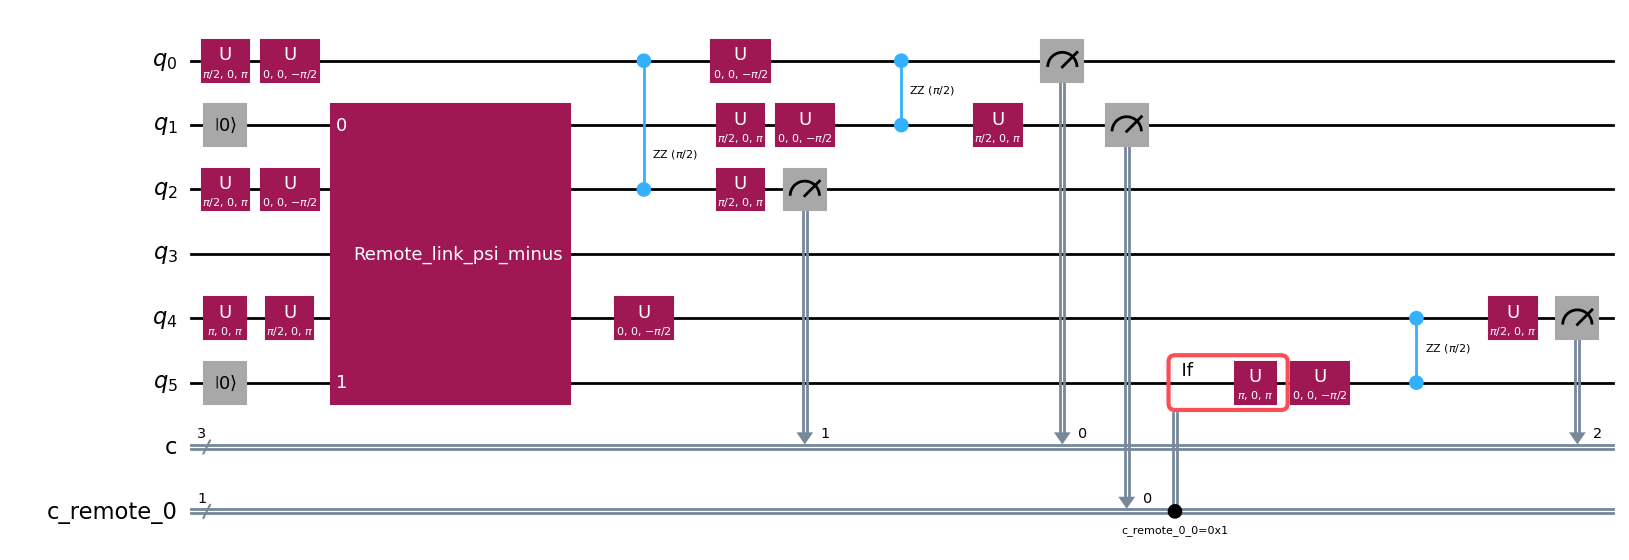

In [979]:
_n = 3
_transpiled = compile_bosonic_circuit(ghz_circuit(_n), _n, 2, bosonic_sdk.BosonicDistributor())
mo.vstack([
    mo.md(f"GHZ circuit with {_n} data qubits has depth {_transpiled.depth()}."),
    _transpiled.draw('mpl')
])

Notice how the remote gates are handled in this transpiled circuit:

1. The algorithm uses $n=3$ data qubits, with two communication qubits $(q_1, q_5)$ to establish one remote link
2. The pair of communication qubits are initialized in $\ket{00}$ and projected by the remote link to the Bell state $\ket{\Psi^-}$
3. One of the communication qubits ($q_1$) entangled with a local qubit ($q_0$) and then measured
4. The measurement result is used to condition a single-qubit rotation on the other communication qubit ($q_5$) before entangling it with another data qubit ($q_4$)

This communication overhead is the DQC version of a SWAP chain, but with one important difference: the gate overhead is constant with system size. No matter how many modules the system may have, the cost of distributing entanglement across two of them is the same. Compare this to a monolithic system, where the size and complexity of the system directly contributes to the cost of entangling two distant qubits (more SWAP gates or longer and more complex physical routing).

Now that we understand how our distributed transpiler works, let's use it to simulate GHZ circuits:

In [980]:
def verify_ghz_bosonic(n, shots=VERIFY_CFG['SHOTS'], traps=2):
    distributor = bosonic_sdk.BosonicDistributor()
    circuit = compile_bosonic_circuit(ghz_circuit(n), n, traps, distributor)
    sim = bosonic_sdk.Simulator()
    circuit = sim.prepare(circuit)
    counts, _ = sim.run_counts(circuit, ignore_c_remote=True, shots=shots, method="automatic")
    data = {
        'backend': 'Bosonic',
        'n': n,
        'depth': circuit.depth(),
        'count0': counts.get('0' * n, 0),
        'count1': counts.get('1' * n, 0),
    }
    return data

In [981]:
bosonic_data = [verify_ghz_bosonic(n) for n in VERIFY_CFG['N_LIST'] if n <= 10]
pd.DataFrame(bosonic_data)

,backend,n,depth,count0,count1
0,Bosonic,3,18,1047,1001
1,Bosonic,4,27,1016,1032
2,Bosonic,5,31,1016,1032
3,Bosonic,6,40,1015,1033
4,Bosonic,7,44,1015,1033
5,Bosonic,8,53,1023,1025
6,Bosonic,9,57,1023,1025
7,Bosonic,10,66,1010,1038


Now we combine these results with our results from the simulated monolithic circuits into a single `DataFrame` for analysis.

In [982]:
verify_df = pd.DataFrame(ibm_data + bosonic_data)
verify_df

,backend,n,depth,count0,count1
0,IBM,3,12,1046,1002
1,IBM,4,18,1035,1013
2,IBM,5,27,1017,1031
3,IBM,6,45,1028,1020
4,IBM,7,50,1042,1006
...,...,...,...,...,...
21,Bosonic,6,40,1015,1033
22,Bosonic,7,44,1015,1033
23,Bosonic,8,53,1023,1025
24,Bosonic,9,57,1023,1025


## Analysis and Comparison

Let's first verify that our circuits have produced the expected measurement distribution.

First, we want to check that we aren't measuring any bitstrings other than $0^n$ and $1^n$, so we can verify:

$$
\frac{
    \texttt{counts}\left[ 0^n \right] + \texttt{counts}\left[ 1^n \right]
}{
    \texttt{SHOTS}
} = 1
$$

In [983]:
verify_df['fidelity'] = (verify_df['count0'] + verify_df['count1']) / VERIFY_CFG['SHOTS']

Also, we want to make sure that both outcomes are being measured with equal probability.

$$
\left\vert
\frac{
    \texttt{counts}\left[ 0^n \right] - \texttt{counts}\left[ 1^n \right]
}{
    \texttt{SHOTS}
} \right\vert \approx 0
$$

In [984]:
verify_df['dispersion'] = np.abs(verify_df['count0'] - verify_df['count1']) / VERIFY_CFG['SHOTS']

Now we just check that:

1. `fidelity` is never below 1
2. `dispersion` is never too far above 0

In [985]:
verify_df.groupby('backend').agg(
    min_fidelity=('fidelity', 'min'),
    max_dispersion=('dispersion', 'max'),
)

,min_fidelity,max_dispersion
backend,,
Bosonic,1.0,0.022461
IBM,1.0,0.040039


Both checks pass! To get a better sense of what the data look like, let's plot the sampled measurement probabilities in 2D space:

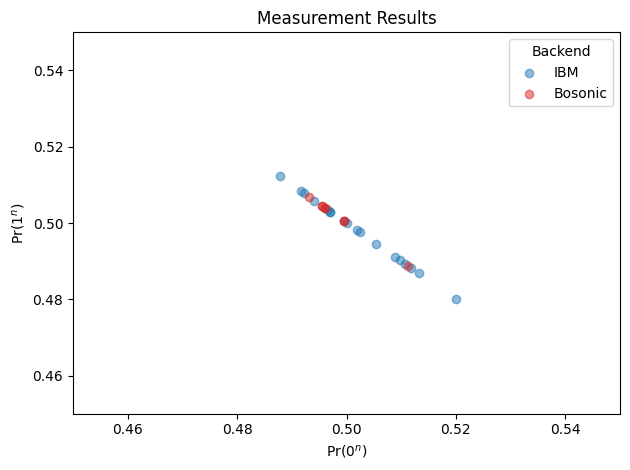

In [986]:
for _backend in ['IBM', 'Bosonic']:
    subdf = verify_df[verify_df['backend'] == _backend]
    style = BACKEND_PLOT_STYLES.get(_backend, {})
    plt.scatter(
        subdf['count0'] / VERIFY_CFG['SHOTS'],
        subdf['count1'] / VERIFY_CFG['SHOTS'],
        label=_backend,
        alpha=0.5,
        color=style.get('color'),
    )

plt.xlabel(r'$\Pr(0^n)$')
plt.xlim(0.45, 0.55)

plt.ylabel(r'$\Pr(1^n)$')
plt.ylim(0.45, 0.55)

plt.title('Measurement Results')
plt.legend(title='Backend')

plt.tight_layout()
plt.show()


Notice that all measurement probabilities:

1. Fall on the line where $\Pr(0^n) + \Pr(1^n) = 1$
2. Are close to $\Pr(0^n) = \Pr(1^n) = 0.5$

# Scaling Behavior

Now that we have verified that our simulators are behaving as expected, we can explore how these circuits scale in each system.

For now we will focus on the following metrics (but you can look at other metrics later):

- `depth`: longest sequential gate path (time-step count)
- `two_qubit_depth`: longest chain of explicit two-qubit-operation layers
- `two_qubit_count`: total number of two-qubit operations
- `total_ops`: total operation count

For each backend and circuit size $n$, we:

1. Build the logical GHZ circuit
2. Compile and measure monolithic metrics
3. Compile and measure distributed metrics, we assume that each module in our distributed system can hold 20 qubits. Each time we exceed a multiple of 20 we must add a new module and introduce a remote link. The module count $k$ is thus given by:  $k = \lceil \frac{n}{20} \rceil$
4. Plot each metric against $n$ to compare growth trends

To keep the comparison fair, we use a single metric engine ([`GateStatistics.stats`](https://github.com/dqc-community/dqcomp/blob/5e72e369cc81efcc279ceb63468a10659f01a872/packages/bosonic-sdk/bosonic_sdk/gate_statistics.py#L157-L163)) for both paths so metric definitions stay consistent.

In [987]:
SCALING_CFG

{'N_LIST': range(3, 128), 'QUBITS_PER_TRAP': 32}

## Defining Metrics

We want to include all of the data we can get. First, let's see what kind of information gets collected in `bosonic_sdk.GateStatistics.stats`:

In [988]:
bosonic_sdk.GateStatistics.stats(
    CircuitConverters.from_qiskit(ghz_circuit(5))
)

{'n_qubits': 5,
 'n_clbits': 5,
 'total_ops': 5,
 'depth': 6,
 'gate_counts': {'h': 1, 'cx': 4},
 'basis_gates': ['cx', 'h'],
 'measure_count': 5,
 'reset_count': 0,
 'barrier_count': 0,
 'local_gate_count': 5,
 'remote_gate_count': 0,
 'total_remote_gates': 0,
 'qubit_teleportation_count': 0,
 'n_classical_gates': 0}

This tells us plenty about local vs. remote operations, but it doesn't provide granular information about which types of local gates were executed, etc. We can collect this directly from the Qiskit circuit representation:

In [989]:
def qiskit_metrics(circuit):
    count_ops = lambda x: sum(inst.operation.name == x for inst in circuit.data)
    gate_ops = [inst for inst in circuit.data if inst.operation.name not in ['measure', 'reset', 'barrier', 'rz']]
    data = {
        'measure_count': count_ops('measure'),
        'reset_count': count_ops('reset'),
        'barrier_count': count_ops('barrier'),
        'single_qubit_count': sum(len(inst.qubits) == 1 for inst in gate_ops),
        'two_qubit_count': sum(len(inst.qubits) == 2 for inst in gate_ops),
        'multi_qubit_count': sum(len(inst.qubits) > 2 for inst in gate_ops),
    }
    return data

In [990]:
def circuit_metrics(circuit):
    converted = CircuitConverters.from_qiskit(circuit)
    data = bosonic_sdk.GateStatistics.stats(converted)
    data.update(qiskit_metrics(circuit))
    return data

## Collecting Data

As before, we set up a pipeline for each backend where we:

1. Construct the logical circuit
2. Transpile to the native gate set of the hardware
3. Collect metrics about the circuit

In [991]:
def scale_ibm(n, constructor=ghz_circuit, backend=FAKE_IBM_BACKEND, **transpile_kwargs):
    circuit = qiskit.transpile(constructor(n), backend=FAKE_IBM_BACKEND, **transpile_kwargs)
    data = {'backend': 'IBM', 'n': n, 'k': 1, 'circuit': circuit}
    return data

In [992]:
def scale_bosonic(
    n,
    constructor=ghz_circuit,
    qubits_per_trap=SCALING_CFG['QUBITS_PER_TRAP'],
    distributor=None,
):
    if distributor is None:
        distributor = bosonic_sdk.BosonicDistributor()
    k = int(np.ceil(n / qubits_per_trap))
    circuit = compile_bosonic_circuit(constructor(n), n, k, distributor)
    data = {'backend': 'Bosonic', 'n': n, 'k': k, 'circuit': circuit}
    return data


Now we loop over every value of $n$ we defined in our config, compile a circuit, and collect the circuit metrics into a `DataFrame`.

In [993]:
if mo.running_in_notebook():
    _iter = mo.status.progress_bar(
        SCALING_CFG['N_LIST'],
        title='Compiling',
        subtitle='Monolithic IBM backend',
    )
else:
    _iter = SCALING_CFG['N_LIST']

ibm_circuits = [scale_ibm(n, optimization_level=3) for n in _iter]

In [994]:
if mo.running_in_notebook():
    _iter = mo.status.progress_bar(
        SCALING_CFG['N_LIST'],
        title='Compiling',
        subtitle='Distributed Bosonic backend',
    )
else:
    _iter = SCALING_CFG['N_LIST']

_distributor = bosonic_sdk.BosonicDistributor()
bosonic_circuits = [scale_bosonic(n, distributor=_distributor) for n in _iter]


In [995]:
circuit_df = pd.DataFrame(ibm_circuits + bosonic_circuits)
circuit_df.loc[:, circuit_df.columns != 'circuit'] # including circuit column breaks marimo display

,backend,n,k
0,IBM,3,1
1,IBM,4,1
2,IBM,5,1
3,IBM,6,1
4,IBM,7,1
...,...,...,...
245,Bosonic,123,4
246,Bosonic,124,4
247,Bosonic,125,4
248,Bosonic,126,4


In [996]:
_metrics = lambda g: pd.Series(circuit_metrics(g['circuit']))
scaling_df = circuit_df.join(circuit_df.apply(_metrics, axis=1))
scaling_df.loc[:, scaling_df.columns != 'circuit']

,backend,n,k,n_qubits,n_clbits,total_ops,depth,gate_counts,basis_gates,measure_count,reset_count,barrier_count,local_gate_count,remote_gate_count,total_remote_gates,qubit_teleportation_count,n_classical_gates,single_qubit_count,two_qubit_count,multi_qubit_count
0,IBM,3,1,127,3,19,12,"{'rz': 11, 'sx': 6, 'ecr': 2}","[ecr, rz, sx]",3,0,0,19,0,0,0,0,6,2,0
1,IBM,4,1,127,4,35,18,"{'rz': 20, 'sx': 12, 'ecr': 3}","[ecr, rz, sx]",4,0,0,35,0,0,0,0,12,3,0
2,IBM,5,1,127,5,62,32,"{'rz': 35, 'sx': 20, 'ecr': 7}","[ecr, rz, sx]",5,0,0,62,0,0,0,0,20,7,0
3,IBM,6,1,127,6,79,39,"{'rz': 44, 'sx': 24, 'ecr': 11}","[ecr, rz, sx]",6,0,0,79,0,0,0,0,24,11,0
4,IBM,7,1,127,7,105,54,"{'rz': 56, 'sx': 34, 'ecr': 15}","[ecr, rz, sx]",7,0,0,105,0,0,0,0,34,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,Bosonic,123,4,246,215,1347,702,"{'u': 1041, 'rzz': 214, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",215,184,0,1255,92,92,92,0,1041,306,0
246,Bosonic,124,4,248,217,1360,709,"{'u': 1051, 'rzz': 216, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",217,186,0,1267,93,93,93,0,1051,309,0
247,Bosonic,125,4,250,218,1365,711,"{'u': 1055, 'rzz': 217, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",218,186,0,1272,93,93,93,0,1055,310,0
248,Bosonic,126,4,252,220,1378,718,"{'u': 1065, 'rzz': 219, 'remote_link_psi_minus...","[remote_link_psi_minus, rzz, u]",220,188,0,1284,94,94,94,0,1065,313,0


## Exploring Results

That's a lot of columns, so let's just remind ourselves quickly of what all the variables are:

In [997]:
list(scaling_df.columns)

['backend',
 'n',
 'k',
 'circuit',
 'n_qubits',
 'n_clbits',
 'total_ops',
 'depth',
 'gate_counts',
 'basis_gates',
 'measure_count',
 'reset_count',
 'barrier_count',
 'local_gate_count',
 'remote_gate_count',
 'total_remote_gates',
 'qubit_teleportation_count',
 'n_classical_gates',
 'single_qubit_count',
 'two_qubit_count',
 'multi_qubit_count']

Let's define a function that plots a metric against the circuit size $n$ and test it for a few different metrics:

In [998]:
def plot_scaling_metric(df, metric, **kwargs):
    group_col = kwargs.get('group_col', 'backend')
    groups = kwargs.get('groups', ['IBM', 'Bosonic'])
    default_styles = globals().get('BACKEND_PLOT_STYLES', {})
    style_overrides = kwargs.get('styles', {})
    ax = kwargs.get('ax')
    owns_fig = ax is None
    if owns_fig:
        _, ax = plt.subplots(figsize=kwargs.get('figsize', None))

    grouped = {
        label: subdf.sort_values('n')
        for label, subdf in df.groupby(group_col, sort=False)
    }
    for _backend in groups:
        subdf = grouped.get(_backend)
        if subdf is None or subdf.empty:
            continue
        style = {
            **default_styles.get(_backend, {}),
            **style_overrides.get(_backend, {}),
        }
        if kwargs.get('scatter', False):
            scatter_style = {
                'marker': style.get('marker', 'o'),
                'alpha': kwargs.get('alpha', 0.5),
            }
            if 'color' in style:
                scatter_style['color'] = style['color']
            if 'markerfacecolor' in style:
                scatter_style['facecolors'] = style['markerfacecolor']
                if 'color' in style:
                    scatter_style['edgecolors'] = style.get('markeredgecolor', style['color'])
            if 'markeredgewidth' in style:
                scatter_style['linewidths'] = style['markeredgewidth']
            ax.scatter(subdf['n'], subdf[metric], label=_backend, **scatter_style)
        else:
            ax.plot(subdf['n'], subdf[metric], label=_backend, **style)

    title = kwargs.get('title', 'Scaling Behavior')
    if title is not None:
        ax.set_title(title)
    ax.set_xlabel(kwargs.get('xlabel', 'Number of Qubits'))
    ax.set_xscale(kwargs.get('xscale', 'linear'))
    ax.set_ylabel(kwargs.get('ylabel', metric))
    ax.set_yscale(kwargs.get('yscale', 'linear'))
    ax.legend(title=kwargs.get('legend_title', 'Backend'))

    if owns_fig:
        plt.tight_layout()
    if kwargs.get('show', True):
        plt.show()


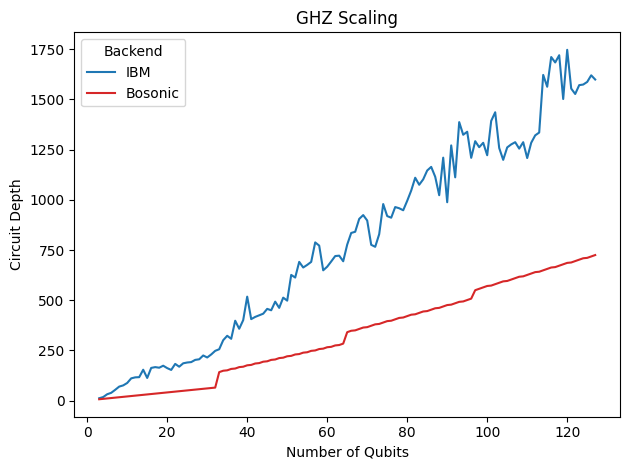

In [999]:
plot_scaling_metric(
    scaling_df, 'depth', title='GHZ Scaling', ylabel='Circuit Depth'
)

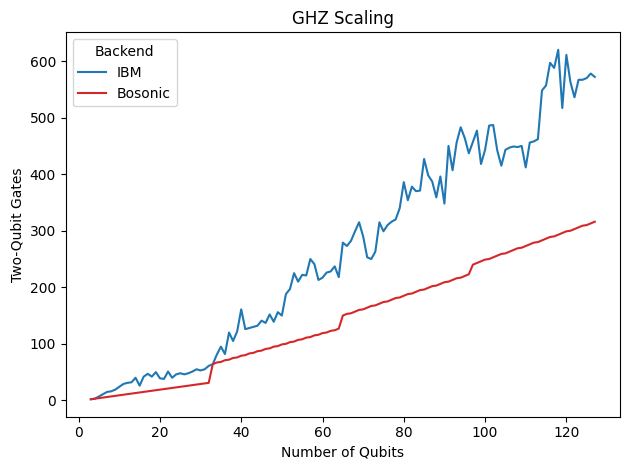

In [1000]:
plot_scaling_metric(
    scaling_df, 'two_qubit_count', title='GHZ Scaling', ylabel='Two-Qubit Gates'
)

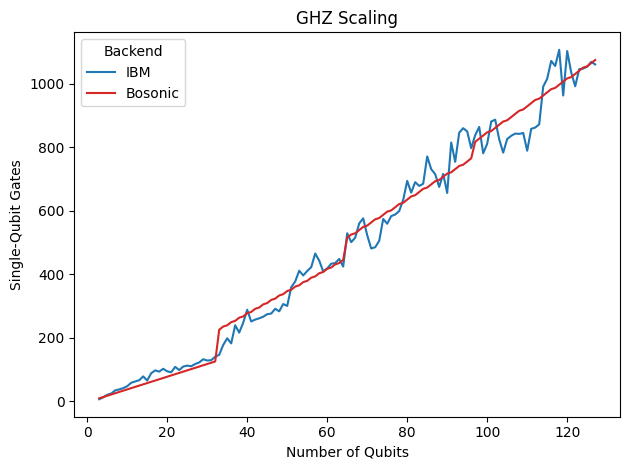

In [1001]:
plot_scaling_metric(
    scaling_df, 'single_qubit_count', title='GHZ Scaling', ylabel='Single-Qubit Gates'
)

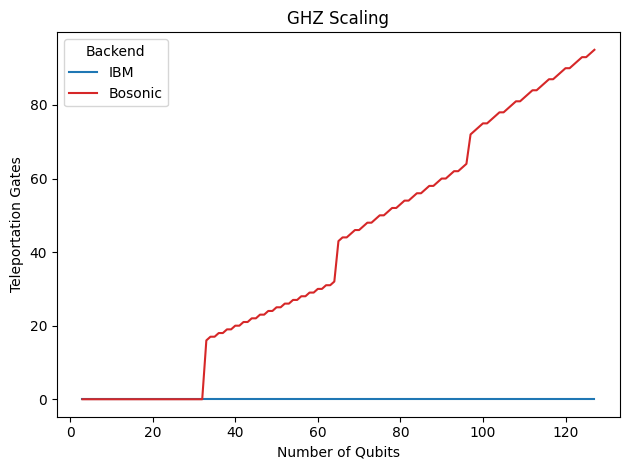

In [1002]:
plot_scaling_metric(
    scaling_df, 'qubit_teleportation_count', title='GHZ Scaling', ylabel='Teleportation Gates'
)

## Interpreting Results

Quantum computation is expensive and error-prone, so we generally want to do as little of it as we can get away with. This means we want circuits with fewer operations and shallower paths.

Two-qubit gates are especially important because they are typically slower and noisier (lower fidelity) than single-qubit gates, which is why we tracked `two_qubit_gates` as a metric.

Connectivity plays a huge role in how many additional gates your circuit needs as it scales. In monolithic nearest-neighbor hardware, non-local interactions require routing through SWAP operations. This routing overhead increases depth and total operation count as circuits grows. In the distributed approach we still have to worry about connectivity, but due to the modularity of the hardware communication costs grow linearly with circuit size (i.e., at the same rate as the logical circuit) rather than exponentially.

# Execution Time

So far we have seen how scaling affects the circuit we are implementing. This is useful for building intuition, but at the end of the day we care about the time-to-solution (TTS) when executing on hardware. Accessing real hardware involves provider cost, queue times, and cloud submission overhead. That cost is worth it when we care about running an application circuit, but here we only care about the scaling behavior. To simplify things, we construct a worst-case model for time-to-solution that incorporates the metrics we care about. 

## Building the Model

To begin, we treat a compiled circuit as a collection of single-qubit gates, two-qubit gates, and remote links. Different gate types can have different execution times, but for a simpler model we assume an average single-qubit gate time $t_{1q}$, an average local two-qubit gate time $t_{2q}$, and a remote-link time $t_{\text{remote}}$. If we further assume that all operations are executed sequentially (a strong assumption, but it provides an upper bound), one shot of the circuit takes:

$$
T_{\text{shot}}(n)=t_{1q}N_{1q}(n) + t_{2q}N_{2q}(n) + t_{\text{remote}}N_{\text{remote}}(n)
$$

We also assume that measurement takes time $t_{\text{measure}}$ per measurement operation, and we include a fixed overhead term for classical control, reset, and other per-shot orchestration costs that are only negligibly affected by qubit count. Our time per shot then becomes:

$$
T_{\text{shot}}(n)=t_{1q}N_{1q}(n) + t_{2q}N_{2q}(n) + t_{\text{remote}}N_{\text{remote}}(n) + t_{\text{measure}}N_{\text{measure}}(n) + t_{\text{overhead}}.
$$

- $t_{1q}$ – execution time of a single-qubit gate
- $N_{1q}$ – number of compiled single-qubit gates
- $t_{2q}$ – execution time of a local two-qubit gate
- $N_{2q}^{\text{local}}$ – number of compiled two-qubit gates within a module
- $t_{\text{remote}}$ – execution time of a remote link between modules, modeled here as $10t_{2q}$ for Bosonic and zero for monolithic IBM rows
- $N_{\text{remote}}$ – number of remote links between modules
- $t_{\text{measure}}$ – measurement time per measurement operation
- $N_{\text{measure}}$ – number of measurement operations in the compiled circuit
- $t_{\text{overhead}}$ – per-shot overhead for classical control and reset
- $n$ – circuit size in number of qubits

In [1003]:
REMOTE_LINK_TWO_QUBIT_TIME_SCALE = 10
LOG_FLOAT_MAX = np.log(np.finfo(float).max)


def _is_missing(value):
    return value is None or pd.isna(value)


def safe_exp(log_value):
    return np.exp(log_value) if log_value < LOG_FLOAT_MAX else np.inf


def remote_link_count(data):
    count = data.get('remote_link_count', data.get('remote_gate_count', 0))
    return 0 if _is_missing(count) else count


def local_two_qubit_count(data):
    count = data.get('local_two_qubit_count', None)
    if not _is_missing(count):
        return count
    return max(data['two_qubit_count'] - remote_link_count(data), 0)


def remote_gate_time(data):
    time = data.get('t_remote', None)
    if not _is_missing(time):
        return time
    hardware = data.get('hardware', data.get('backend', None))
    return REMOTE_LINK_TWO_QUBIT_TIME_SCALE * data['t2q'] if hardware == 'Bosonic' else 0


def remote_gate_error(data):
    error = data.get('e_remote', None)
    return data['e2q'] if _is_missing(error) else error


def add_remote_link_terms(df):
    data = df.copy()
    if 'remote_link_count' not in data:
        if 'remote_gate_count' in data:
            data['remote_link_count'] = data['remote_gate_count'].fillna(0)
        else:
            data['remote_link_count'] = 0
    data['remote_link_count'] = data['remote_link_count'].fillna(0)
    if 'local_two_qubit_count' not in data:
        data['local_two_qubit_count'] = (
            data['two_qubit_count'] - data['remote_link_count']
        ).clip(lower=0)
    data['local_two_qubit_count'] = data['local_two_qubit_count'].fillna(0)
    return data


def T_shot(data):
    t_compute = (
        data['t1q'] * data['single_qubit_count'] +
        data['t2q'] * local_two_qubit_count(data) +
        remote_gate_time(data) * remote_link_count(data) +
        data['t_meas'] * data['measure_count']
    )
    return t_compute + data['t_overhead']

In an ideal (or at least fault-tolerant) world, we would almost surely obtain the intended result of each shot, so TTS is just $T_\text{shot}$ times the number of shots. (We may still want to run multiple shots because we care about the distribution over measurements and not a single solution bitstring.) But taking into account noise (and the absence of error correction in our circuits) the probability of measuring the correct result vanishes exponentially with circuit depth. We will take a look at what circuits with error correcting codes look like in a future demo, but for our present model we assume that the success probability of the full circuit is the product of the success probabilities of the gates that make it up:

$$
P_{\text{success}}(n)=
(1-\epsilon_{1q})^{N_{1q}(n)}
(1-\epsilon_{2q})^{N_{2q}^{\text{local}}(n)}
(1-\epsilon_{\text{remote}})^{N_{\text{remote}}(n)}.
$$

- $\epsilon_{1q}$ – error rate of a single-qubit gate
- $\epsilon_{2q}$ – error rate of a local two-qubit gate
- $\epsilon_{\text{remote}}$ – error rate of a remote link, currently set equal to $\epsilon_{2q}$
- $N_{1q}(n)$ – number of single-qubit gates in the compiled circuit
- $N_{2q}^{\text{local}}(n)$ – number of local two-qubit gates in the compiled circuit
- $N_{\text{remote}}(n)$ – number of remote links in the compiled circuit

In [1004]:
def shot_success_log_prob(data):
    """Independent-operation success proxy from 1Q/2Q/remote error rates."""
    return (
        data['single_qubit_count'] * np.log1p(-data['e1q']) +
        local_two_qubit_count(data) * np.log1p(-data['e2q']) +
        remote_link_count(data) * np.log1p(-remote_gate_error(data))
    )

If only a fraction $P_{\text{success}}$ of shots succeed, then the expected time-to-solution increases by a factor of $1/P_{\text{success}}$. Using that correction, and keeping the remote-link term inside both $T_{\text{shot}}$ and $P_{\text{success}}$, the success-adjusted model becomes:

$$
\mathrm{TTS}(n,k) \approx
{S} \cdot
\frac{T_{\text{shot}}(n)}{P_{\text{success}}(n)}.
$$

Now with our model defined the next step is to define the parameters we use in our model. Below we define some numbers for gate times and errors, these numbers are taken from real data to maintain the model as accurate as possible. 

In [1005]:
device_df = pd.DataFrame(
    [
        {
            "backend": "IBM",
            "t1q": 5.7e-8,
            "t2q": 5.4e-7,
            "t_meas": 1.2e-6,
            "t_overhead": 2e-4,
            "e1q": 5.6e-4,
            "e2q": 1.0e-2,
        },
        {
            "backend": "Bosonic",
            "t1q": 1e-6,
            "t2q": 3e-5,
            "t_meas": 4e-4,
            "t_overhead": 1e-3,
            "e1q": 1e-6,
            "e2q": 1e-4,
        },
    ]
)
device_df

,backend,t1q,t2q,t_meas,t_overhead,e1q,e2q
0,IBM,5.700000e-08,5.400000e-07,0.000001,0.0002,0.000560,0.0100
1,Bosonic,1.000000e-06,3.000000e-05,0.000400,0.0010,0.000001,0.0001


We can compare the values we set for the IBM backend to the values recorded in the backend itself (expand the code if you want to see how this is done):

In [1006]:
def instruction_data(inst, backend=FAKE_IBM_BACKEND):
    op, qtuple = inst
    data = {
        'name': op.name,
        'qubits': qtuple,
    }
    props = backend.target[op.name].get(qtuple) if qtuple else None
    if props:
        data.update({
            'duration': props.duration,
            'error': props.error,
        })

    return data


op_df = pd.DataFrame(
    [instruction_data(inst) for inst in FAKE_IBM_BACKEND.target.instructions]
)

op_df[
    op_df['error'] < 1 # ignore ecr gates with error = 1
].melt(
    id_vars=['name'],
    value_vars=['duration','error'],
    var_name='variable',
    value_name='value',
).groupby(
    ['name', 'variable']
).agg(
    mean=('value', 'mean'),
).reset_index().pivot_table(
    index='name',
    columns='variable',
    values='mean',
)

variable,duration,error
name,,
ecr,5.360198e-07,0.010183
id,5.688889e-08,0.000556
measure,1.216000e-06,0.041477
rz,0.000000e+00,0.000000
sx,5.688889e-08,0.000556
x,5.688889e-08,0.000556


We can merge this device data directly into our experiment data to compute execution times at each row.

In [1007]:
_merged = scaling_df.merge(device_df, on='backend')
_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   backend                    250 non-null    object 
 1   n                          250 non-null    int64  
 2   k                          250 non-null    int64  
 3   circuit                    250 non-null    object 
 4   n_qubits                   250 non-null    int64  
 5   n_clbits                   250 non-null    int64  
 6   total_ops                  250 non-null    int64  
 7   depth                      250 non-null    int64  
 8   gate_counts                250 non-null    object 
 9   basis_gates                250 non-null    object 
 10  measure_count              250 non-null    int64  
 11  reset_count                250 non-null    int64  
 12  barrier_count              250 non-null    int64  
 13  local_gate_count           250 non-null    int64  

## Applying the Model

Now that we have defined the basic model functions defined, we can start building some functions to collect simulation data.

In [1008]:
def tts_data_series(df, shots=TTS_CFG['SHOTS']):
    data = {
        't_remote': remote_gate_time(df),
        'e_remote': remote_gate_error(df),
        'log_pr_success': shot_success_log_prob(df),
    }
    data['t_shot'] = T_shot(df)
    data['log_t_shot'] = np.log(data['t_shot'])
    data['t_shot_compute'] = data['t_shot'] - df['t_overhead']
    data['log_tts_ideal'] = np.log(shots) + np.log(data['t_shot'])
    data['log_tts'] = data['log_tts_ideal'] - data['log_pr_success']
    data['tts'] = safe_exp(data['log_tts'])
    return pd.Series(data)

All we have to do is apply this function to our existing simulation data.

In [1009]:
tts_input_df = add_remote_link_terms(scaling_df)
tts_df = tts_input_df.join(
    tts_input_df.merge(device_df, on='backend').apply(tts_data_series, axis=1)
)
tts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   backend                    250 non-null    object 
 1   n                          250 non-null    int64  
 2   k                          250 non-null    int64  
 3   circuit                    250 non-null    object 
 4   n_qubits                   250 non-null    int64  
 5   n_clbits                   250 non-null    int64  
 6   total_ops                  250 non-null    int64  
 7   depth                      250 non-null    int64  
 8   gate_counts                250 non-null    object 
 9   basis_gates                250 non-null    object 
 10  measure_count              250 non-null    int64  
 11  reset_count                250 non-null    int64  
 12  barrier_count              250 non-null    int64  
 13  local_gate_count           250 non-null    int64  

## Exploring Results

Since we're using the same data structure, we can also re-use our plotting funtions from the previous section:

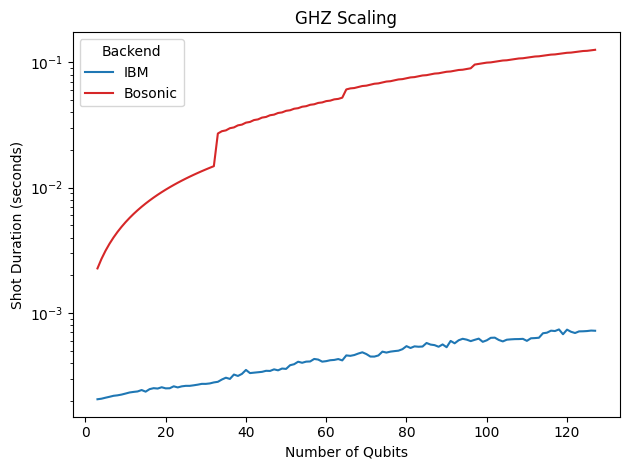

In [1010]:
plot_scaling_metric(
    tts_df, 't_shot', title='GHZ Scaling', ylabel='Shot Duration (seconds)', yscale='log',
)

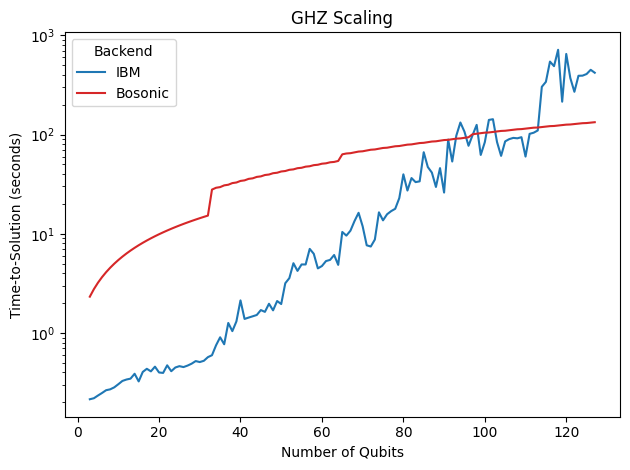

In [1011]:
plot_scaling_metric(
    tts_df, 'tts', title='GHZ Scaling', ylabel='Time-to-Solution (seconds)', yscale='log',
)

## Interpreting Results

Both of these plots show the same pattern. The monolithic superconducting backend has lower shot times and TTS everywhere, but both of them grow quickly with circuit size.

1. Shot time grows because of the number of SWAP operations necessary to entangle increasingly distant qubits.
2. TTS grows exponential because not only are shots getting longer, but gate depth and therefore shot fidelity is decreasing, which exponentially increases the number of shots required to reach a solution.

For the trapped-ion backend, shot speed and TTS is much higher, but both grow much more slowly. Shot speed grows approximately linearly, since each additional qubit is just another direct CNOT. TTS grows faster, but the high physical fidelities of trapped ions keep the extra number of shots from growing too quickly.

We've reached the maximum number of qubits in the `FakeSherbrooke` backend, but it looks like the two TTS lines would cross if we could keep adding qubits. So let's try that!

# Extrapolating to Utility Scale


This first extrapolation gives us a useful baseline, but we are limited by data collected on the `FakeSherbrooke` backend which has a limit of 127 qubits. Recall that we are interested in qubit counts where we can run algorithms that demonstrate quantum advantage, somewhere around 1000-10,0000 qubits. The next step is to extrapolate to higher qubit counts. To make the extrapolation less dependent on that small fit window, we also build a custom qiskit backend with the same Sherbrooke-style heavy-hex topology and basis gates, but without the 127-qubit cap. We first validate the custom backend against `FakeSherbrooke` by checking that all measurable metrics match. Once we verify that our custom backend is idential to the official `FakeSherbrook` we run larger GHZ circuits through the custom backend. This approach works great for about 1000 qubits but afterwards this computation becomes unrealitic. Once he hit this wall we fit a linear model and extrapolate. 


Let's start by copying the properties of the fakesherbrooke backend to make our custom backend. 


In [1012]:
if 'FAKE_IBM_BACKEND' not in globals():
    FAKE_IBM_BACKEND = qiskit_ibm_runtime.fake_provider.FakeSherbrooke()

TRANSPILE_SEED = VERIFY_CFG.get('SEED', 1234)
SHERBROOKE_FACTORY = SherbrookeLikeBackendFactory(
    FAKE_IBM_BACKEND,
    seed=TRANSPILE_SEED,
)

FAKE_SHERBROOKE_CONFIG = SHERBROOKE_FACTORY.reference_config
FAKE_SHERBROOKE_COORDS = SHERBROOKE_FACTORY.reference_coords
FAKE_SHERBROOKE_EDGES = SHERBROOKE_FACTORY.reference_edges
SHERBROOKE_BASIS_GATES = SHERBROOKE_FACTORY.basis_gates
SHERBROOKE_DIRECTION_SIGNS = SHERBROOKE_FACTORY.direction_signs
SHERBROOKE_BACKEND_CACHE = SHERBROOKE_FACTORY.backend_cache
make_sherbrooke_like_backend = SHERBROOKE_FACTORY.make_backend

custom_127_backend, custom_127_meta = make_sherbrooke_like_backend(
    127,
    return_metadata=True,
)
custom_127_backend


Now that we have created our custom backend, we validate it against the official `FakeSherbrooke` backend. We use a few small circuit families and compare compiled metrics across both backends; the topology checks run silently and the plots should overlap closely.


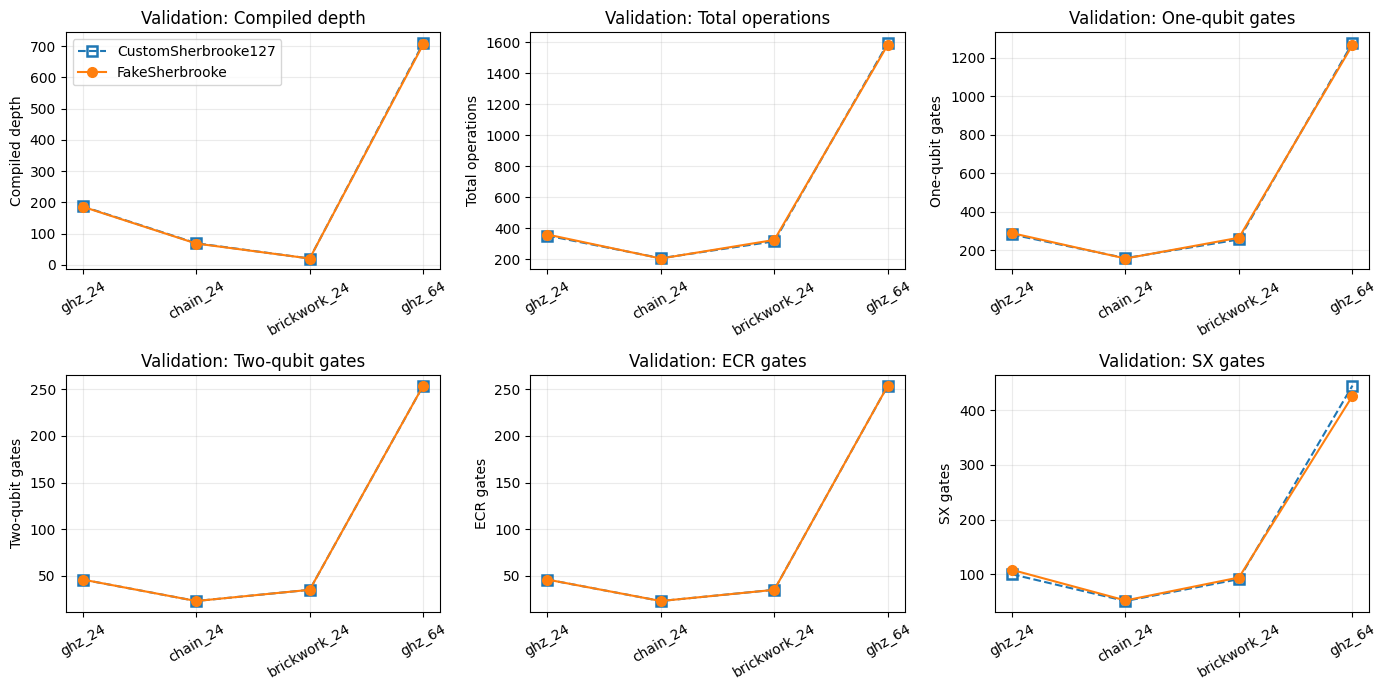

In [1013]:
fake_coords = FAKE_SHERBROOKE_COORDS
fake_edges = FAKE_SHERBROOKE_EDGES
custom_edges = {tuple(edge) for edge in custom_127_meta['edges']}

topology_validation = {
    'coords_match': custom_127_meta['coords'] == fake_coords,
    'directed_edges_match': custom_edges == fake_edges,
    'undirected_edges_match': {tuple(sorted(edge)) for edge in custom_edges}
    == {tuple(sorted(edge)) for edge in fake_edges},
    'qubits_match': custom_127_backend.num_qubits == FAKE_IBM_BACKEND.num_qubits,
    'basis_gates_match': set(SHERBROOKE_BASIS_GATES).issubset(
        set(custom_127_backend.operation_names)
    ),
}
assert all(topology_validation.values()), topology_validation

VALIDATION_CIRCUITS = {
    'ghz_24': ghz_circuit(24),
    'chain_24': chain_circuit(24),
    'brickwork_24': brickwork_circuit(24),
    'ghz_64': ghz_circuit(64),
}
VALIDATION_BACKENDS = [
    ('FakeSherbrooke', FAKE_IBM_BACKEND),
    ('CustomSherbrooke127', custom_127_backend),
]

validation_compile_df = pd.DataFrame(
    transpile_metric_summary(
        circuit_name,
        circuit,
        backend_label,
        backend,
        seed_transpiler=TRANSPILE_SEED,
    )
    for circuit_name, circuit in VALIDATION_CIRCUITS.items()
    for backend_label, backend in VALIDATION_BACKENDS
)

validation_circuit_order = list(VALIDATION_CIRCUITS)
validation_metric_specs = [
    ('depth', 'Compiled depth'),
    ('total_ops', 'Total operations'),
    ('single_qubit_count', 'One-qubit gates'),
    ('two_qubit_count', 'Two-qubit gates'),
    ('ecr', 'ECR gates'),
    ('sx', 'SX gates'),
]
validation_plot_styles = {
    'FakeSherbrooke': {
        'linestyle': '-',
        'marker': 'o',
        'markersize': 7,
    },
    'CustomSherbrooke127': {
        'linestyle': '--',
        'marker': 's',
        'markersize': 7,
        'markerfacecolor': 'none',
        'markeredgewidth': 1.8,
    },
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, (metric, ylabel) in zip(axes.ravel(), validation_metric_specs):
    for backend_label, subdf in validation_compile_df.groupby('backend'):
        subdf = subdf.set_index('circuit').loc[validation_circuit_order]
        ax.plot(
            validation_circuit_order,
            subdf[metric],
            label=backend_label,
            **validation_plot_styles.get(backend_label, {}),
        )
    ax.set_title(f'Validation: {ylabel}')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.25)

axes[0, 0].legend()
plt.tight_layout()
plt.show()

With the custom backend validated, we can collect data points above 127 qubits. We collect data points up to around 1000 qubits, numbers beyond that become too computationally expensive. We take the collected data and use that to fit a model to extrapolate to higher qubit counts. 

The benchmark cells below use cached data to generate plots. If you would like to rerun the data and collect it yourself simply change the variable `EXTENDED_SCALING_CFG['REBUILD_CACHE']` to `True`.  

In [1014]:
EXTENDED_SCALING_CFG = {
    'MIN_QUBITS': 128,
    'MAX_QUBITS': 1000,
    'N_POINTS': 400,
    'REBUILD_CACHE': False,
    'COMPILE_MISSING_IBM': False,
    'CACHE_DIR': _PROJECT_ROOT / 'Tutorial_Notebooks' / 'Jupyter_Notebooks' / 'cache',
}
EXTENDED_SCALING_CFG['N_LIST'] = unique_int_linspace(
    EXTENDED_SCALING_CFG['MIN_QUBITS'],
    EXTENDED_SCALING_CFG['MAX_QUBITS'],
    EXTENDED_SCALING_CFG['N_POINTS'],
)
assert len(EXTENDED_SCALING_CFG['N_LIST']) == EXTENDED_SCALING_CFG['N_POINTS']

EXTENDED_CACHE_DIR = EXTENDED_SCALING_CFG['CACHE_DIR']
IBM_COMPILE_CACHE_PATH = EXTENDED_CACHE_DIR / 'ghz_ibm_custom_heavy_hex_compile_cache.json'
BOSONIC_COMPILE_CACHE_PATH = EXTENDED_CACHE_DIR / 'ghz_bosonic_distributed_compile_cache.json'
BENCHMARK_COMPILE_CACHE_PATH = EXTENDED_CACHE_DIR / 'ghz_compile_benchmark_metrics.json'
COMPILE_PROGRESS_BAR = mo.status.progress_bar if mo.running_in_notebook() else None


In [1049]:
IBM_HEAVY_HEX_SERIES = 'IBM custom heavy-hex'
IBM_COMPILE_CACHE_METADATA = {
    'cache_version': 1,
    'benchmark': 'ghz_custom_sherbrooke_compile_metrics',
    'series': IBM_HEAVY_HEX_SERIES,
    'constructor': 'ghz_circuit',
    'backend_family': 'custom_sherbrooke_like_heavy_hex',
    'basis_gates': list(SHERBROOKE_BASIS_GATES),
}

ibm_compile_cache_df = load_compile_cache(
    IBM_COMPILE_CACHE_PATH,
    IBM_COMPILE_CACHE_METADATA,
    rebuild_cache=EXTENDED_SCALING_CFG['REBUILD_CACHE'],
)
extended_compile_df, ibm_compile_cache_df, _skipped = collect_compile_rows(
    ibm_compile_cache_df,
    IBM_COMPILE_CACHE_PATH,
    IBM_COMPILE_CACHE_METADATA,
    IBM_HEAVY_HEX_SERIES,
    EXTENDED_SCALING_CFG['N_LIST'],
    lambda n: ibm_heavy_hex_metric_summary(
        n,
        constructor=ghz_circuit,
        backend_factory=SHERBROOKE_FACTORY,
        series=IBM_HEAVY_HEX_SERIES,
        seed_transpiler=TRANSPILE_SEED,
    ),
    compile_missing=EXTENDED_SCALING_CFG['COMPILE_MISSING_IBM'],
    subtitle='Monolithic heavy-hex backend',
    progress_bar=COMPILE_PROGRESS_BAR,
)

if extended_compile_df.empty:
    raise ValueError("No cached IBM heavy-hex rows matched EXTENDED_SCALING_CFG['N_LIST'].")
if _skipped:
    print(
        f'Loaded {len(extended_compile_df)} cached IBM rows and skipped {_skipped} uncached rows. '
        "Set EXTENDED_SCALING_CFG['COMPILE_MISSING_IBM'] = True to fill the gaps.",
        flush=True,
    )

BENCHMARK_N_LIST = sorted(extended_compile_df['n'].astype(int).unique())


Loaded 110 cached IBM rows and skipped 290 uncached rows. Set EXTENDED_SCALING_CFG['COMPILE_MISSING_IBM'] = True to fill the gaps.


Now compile the same GHZ sizes with the Bosonic distributed backend. Recall that once we exceed the number of qubits available in a single module we need to add another module and create a remote link. The number of modules is set by `ceil(n / BOSONIC_QUBITS_PER_MODULE)`, which takes the floor division of the total number of qubits by the amount of qubits per module which is set to 128.

In [1016]:
BOSONIC_DISTRIBUTED_SERIES = 'Bosonic distributed'
BOSONIC_QUBITS_PER_MODULE = TTS_CFG['QUBITS_PER_TRAP']
BOSONIC_COMPILE_CACHE_METADATA = {
    'cache_version': 1,
    'benchmark': 'ghz_bosonic_distributed_compile_metrics',
    'series': BOSONIC_DISTRIBUTED_SERIES,
    'constructor': 'ghz_circuit',
    'distributor': 'BosonicDistributor',
    'qubits_per_module': BOSONIC_QUBITS_PER_MODULE,
}

bosonic_compile_cache_df = load_compile_cache(
    BOSONIC_COMPILE_CACHE_PATH,
    BOSONIC_COMPILE_CACHE_METADATA,
    rebuild_cache=EXTENDED_SCALING_CFG['REBUILD_CACHE'],
)
bosonic_compile_df, bosonic_compile_cache_df, _ = collect_compile_rows(
    bosonic_compile_cache_df,
    BOSONIC_COMPILE_CACHE_PATH,
    BOSONIC_COMPILE_CACHE_METADATA,
    BOSONIC_DISTRIBUTED_SERIES,
    BENCHMARK_N_LIST,
    lambda n: bosonic_metric_summary(
        n,
        constructor=ghz_circuit,
        scale_bosonic_fn=scale_bosonic,
        circuit_metrics_fn=circuit_metrics,
        series=BOSONIC_DISTRIBUTED_SERIES,
        qubits_per_trap=BOSONIC_QUBITS_PER_MODULE,
    ),
    subtitle='Distributed Bosonic backend',
    progress_bar=COMPILE_PROGRESS_BAR,
)

benchmark_compile_df = pd.concat(
    [extended_compile_df, bosonic_compile_df],
    ignore_index=True,
    sort=False,
)
BENCHMARK_COMPILE_CACHE_METADATA = {
    'cache_version': 1,
    'benchmark': 'ghz_compile_benchmark_metrics',
    'series': [IBM_HEAVY_HEX_SERIES, BOSONIC_DISTRIBUTED_SERIES],
    'n_list': BENCHMARK_N_LIST,
    'bosonic_qubits_per_module': BOSONIC_QUBITS_PER_MODULE,
}
save_compile_cache(
    BENCHMARK_COMPILE_CACHE_PATH,
    BENCHMARK_COMPILE_CACHE_METADATA,
    benchmark_compile_df,
)


Finally, apply the same TTS model used earlier in the notebook.

In [1017]:
benchmark_tts_df = apply_tts_model(
    benchmark_compile_df,
    device_df,
    add_remote_link_terms,
    tts_data_series,
)


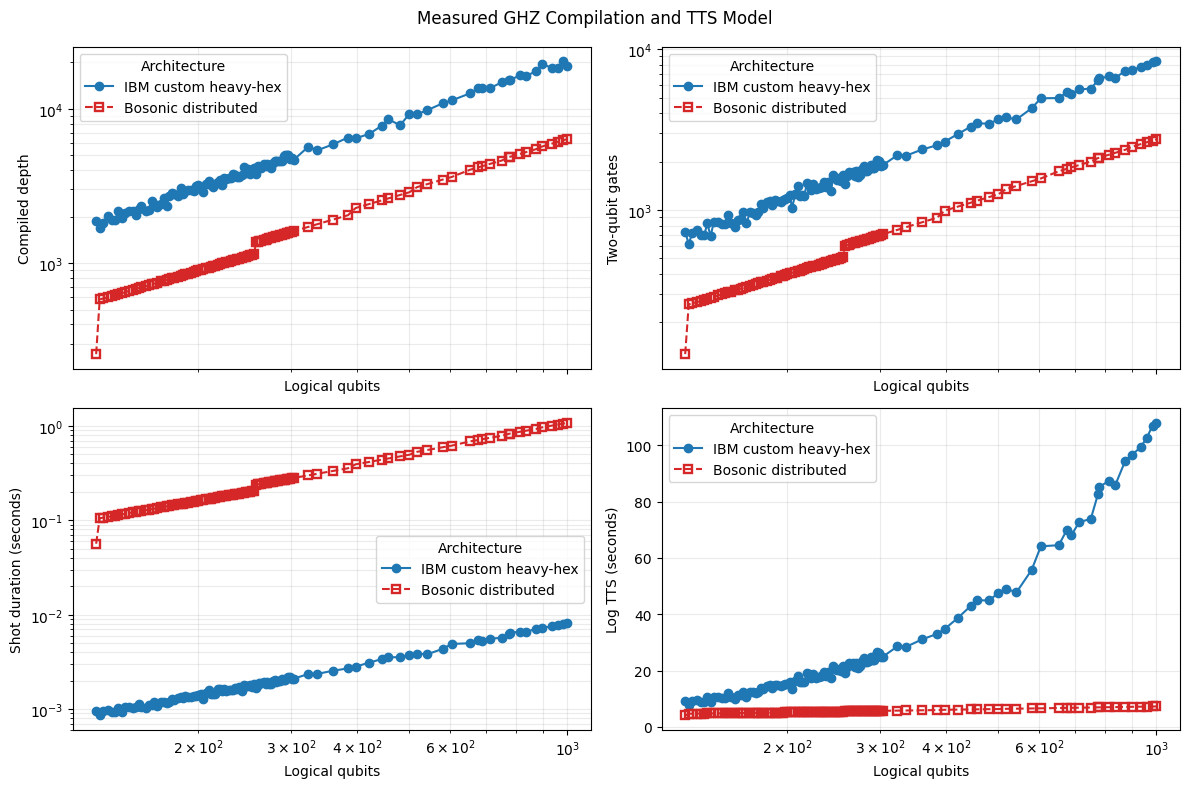

In [1018]:
series_styles = {
    IBM_HEAVY_HEX_SERIES: {
        'color': IBM_PLOT_COLOR,
        'linestyle': '-',
        'marker': 'o',
        'markersize': 6,
    },
    BOSONIC_DISTRIBUTED_SERIES: {
        'color': BOSONIC_PLOT_COLOR,
        'linestyle': '--',
        'marker': 's',
        'markersize': 6,
        'markerfacecolor': 'none',
        'markeredgewidth': 1.7,
    },
}
benchmark_series_order = [IBM_HEAVY_HEX_SERIES, BOSONIC_DISTRIBUTED_SERIES]
benchmark_plot_opts = {
    'series_order': benchmark_series_order,
    'series_styles': series_styles,
}

fig, axes = plot_benchmark_grid(
    benchmark_tts_df,
    [
        ('depth', 'Compiled depth', 'log'),
        ('two_qubit_count', 'Two-qubit gates', 'log'),
        ('t_shot', 'Shot duration (seconds)', 'log'),
        ('log_tts', 'Log TTS (seconds)', 'linear'),
    ],
    'Measured GHZ Compilation and TTS Model',
    **benchmark_plot_opts,
)


### Individual export plots

Run the cells below to render each benchmark view as its own figure.

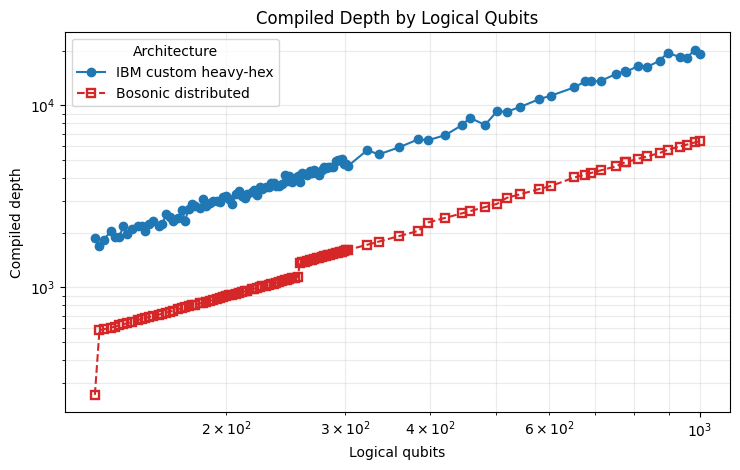

In [1019]:
fig, ax = plot_benchmark_metric(
    benchmark_tts_df,
    'depth',
    'Compiled depth',
    yscale='log',
    title='Compiled Depth by Logical Qubits',
    **benchmark_plot_opts,
)
plt.show()


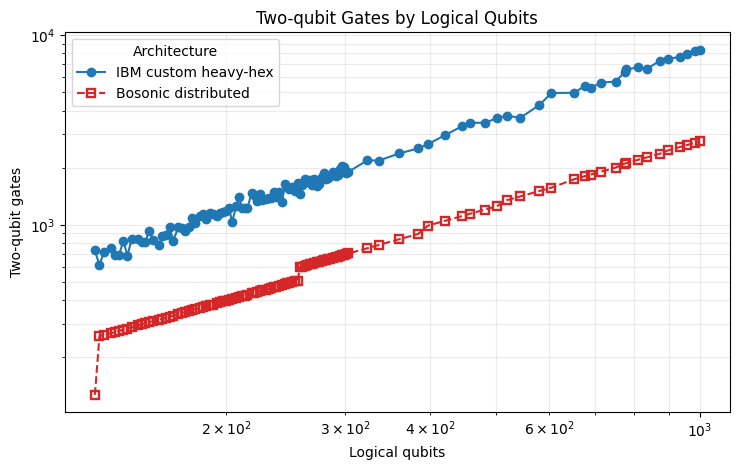

In [1020]:
fig, ax = plot_benchmark_metric(
    benchmark_tts_df,
    'two_qubit_count',
    'Two-qubit gates',
    yscale='log',
    title='Two-qubit Gates by Logical Qubits',
    **benchmark_plot_opts,
)
plt.show()


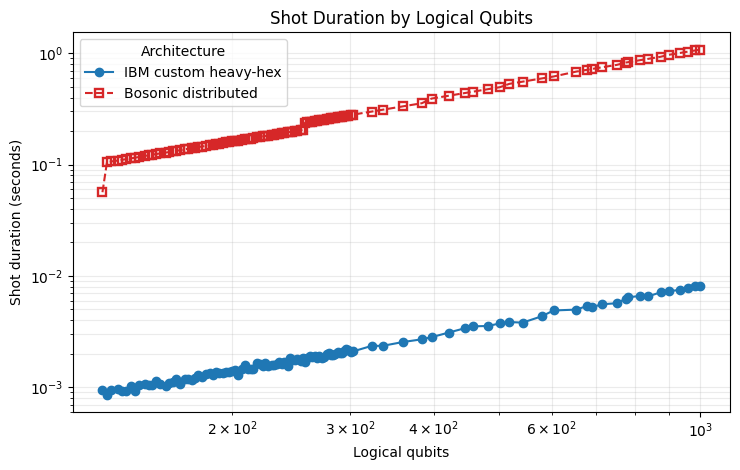

In [1021]:
fig, ax = plot_benchmark_metric(
    benchmark_tts_df,
    't_shot',
    'Shot duration (seconds)',
    yscale='log',
    title='Shot Duration by Logical Qubits',
    **benchmark_plot_opts,
)
plt.show()


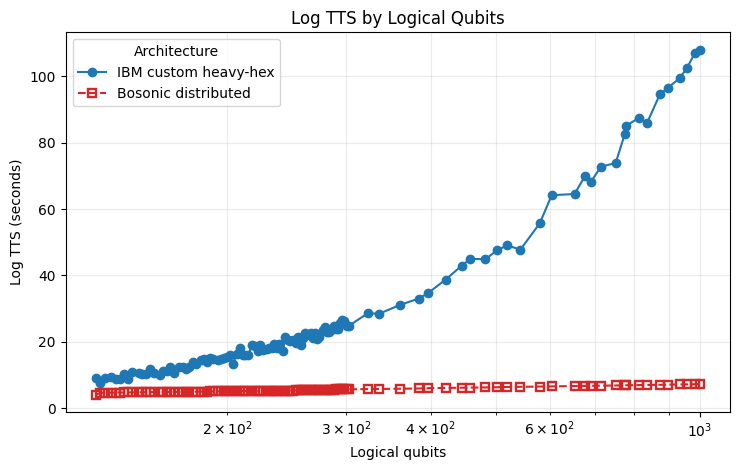

In [1022]:
fig, ax = plot_benchmark_metric(
    benchmark_tts_df,
    'log_tts',
    'Log TTS (seconds)',
    yscale='linear',
    title='Log TTS by Logical Qubits',
    **benchmark_plot_opts,
)
plt.show()


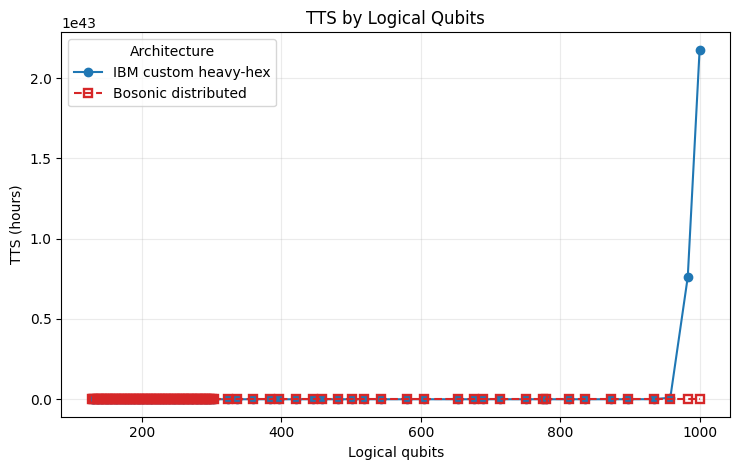

In [1023]:
fig, ax = plot_benchmark_metric(
    benchmark_tts_df,
    'tts_hours',
    'TTS (hours)',
    yscale='linear',
    title='TTS by Logical Qubits',
    xscale='linear',
    **benchmark_plot_opts,
)
plt.show()


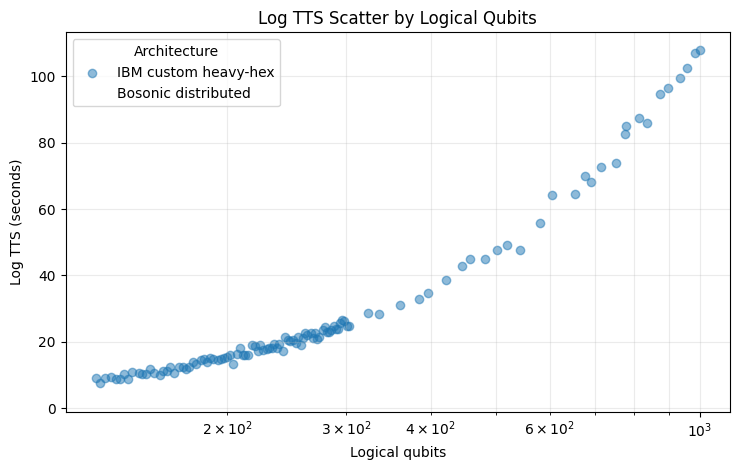

In [1024]:
fig, ax = plot_benchmark_metric(
    benchmark_tts_df,
    'log_tts',
    'Log TTS (seconds)',
    yscale='linear',
    title='Log TTS Scatter by Logical Qubits',
    scatter=True,
    **benchmark_plot_opts,
)
plt.show()


### Extrapolate from the dense measured sweep

 Now that we have gatherer more data we can see that the trendlines look to be linear. Next, we fit a simple linear model to the measured operation counts and project those metrics to utility-scale circuit sizes to see how monolithic and distributed approaches compare as we scale up. In the graphs below data we collected from the custom backend and our extrapolation is differentiated by the dotted line. 

In [1025]:
EXTENDED_EXTRAPOLATION_CFG = {
    'MAX_QUBITS': 100_000,
    'N_POINTS': 160,
    'FIT_METRICS': [
        'backend_qubits',
        'depth',
        'single_qubit_count',
        'local_two_qubit_count',
        'remote_link_count',
        'measure_count',
    ],
}
EXTENDED_EXTRAPOLATION_CFG['N_LIST'] = unique_int_logspace(
    EXTENDED_SCALING_CFG['MAX_QUBITS'],
    EXTENDED_EXTRAPOLATION_CFG['MAX_QUBITS'],
    EXTENDED_EXTRAPOLATION_CFG['N_POINTS'],
)

extended_extrapolated_compile_df = extended_gate_count_prediction(
    benchmark_tts_df,
    EXTENDED_EXTRAPOLATION_CFG['N_LIST'],
    fit_metrics=EXTENDED_EXTRAPOLATION_CFG['FIT_METRICS'],
    fit_max_qubits=EXTENDED_SCALING_CFG['MAX_QUBITS'],
    bosonic_qubits_per_module=BOSONIC_QUBITS_PER_MODULE,
)
extended_extrapolation_df = apply_tts_model(
    extended_extrapolated_compile_df,
    device_df,
    add_remote_link_terms,
    tts_data_series,
)


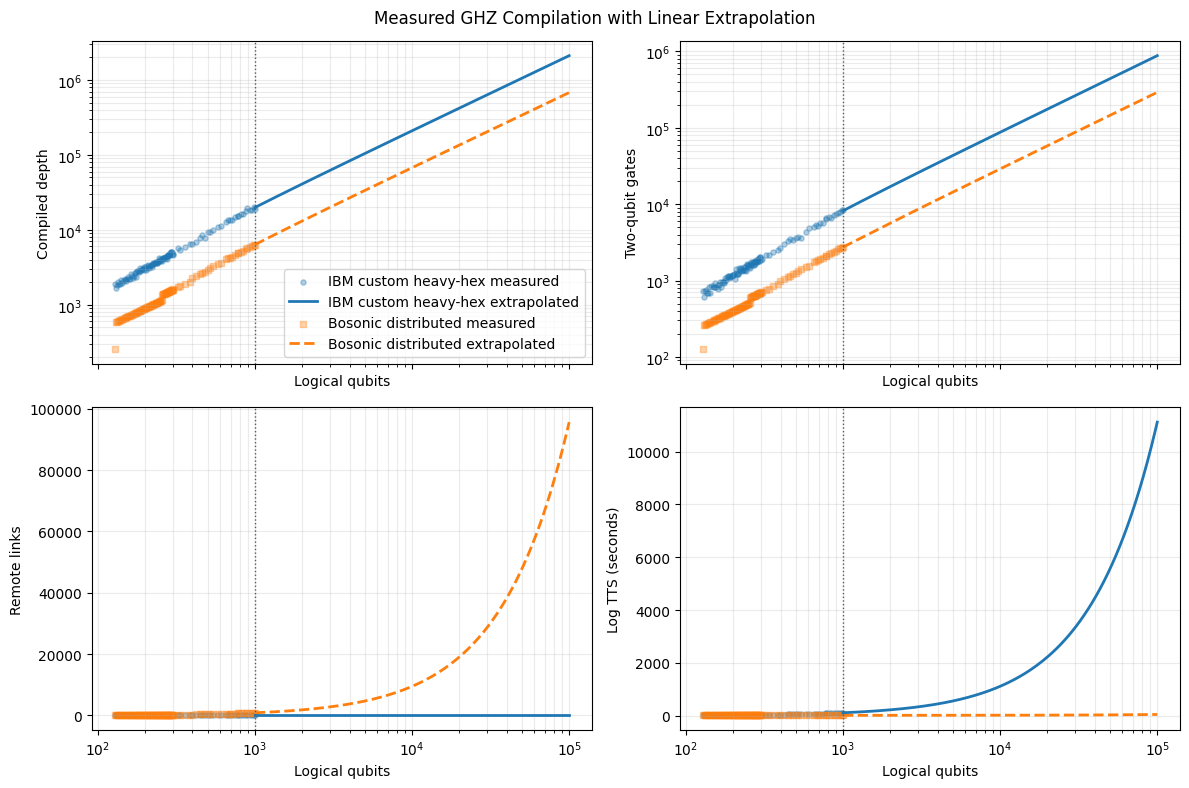

In [1026]:
benchmark_tts_by_series = sorted_series_groups(benchmark_tts_df)
extended_extrapolation_by_series = sorted_series_groups(extended_extrapolation_df)
projection_plot_specs = [
    ('depth', 'Compiled depth', 'log'),
    ('two_qubit_count', 'Two-qubit gates', 'log'),
    ('remote_link_count', 'Remote links', 'linear'),
    ('log_tts', 'Log TTS (seconds)', 'linear'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (metric, ylabel, yscale) in zip(axes.ravel(), projection_plot_specs):
    plot_measured_and_extrapolated_metric(
        benchmark_tts_by_series,
        extended_extrapolation_by_series,
        metric,
        ylabel,
        yscale=yscale,
        cutoff_n=EXTENDED_SCALING_CFG['MAX_QUBITS'],
        ax=ax,
        legend=False,
        show=False,
        **benchmark_plot_opts,
    )
axes[0, 0].legend()
fig.suptitle('Measured GHZ Compilation with Linear Extrapolation')
fig.tight_layout()
plt.show()


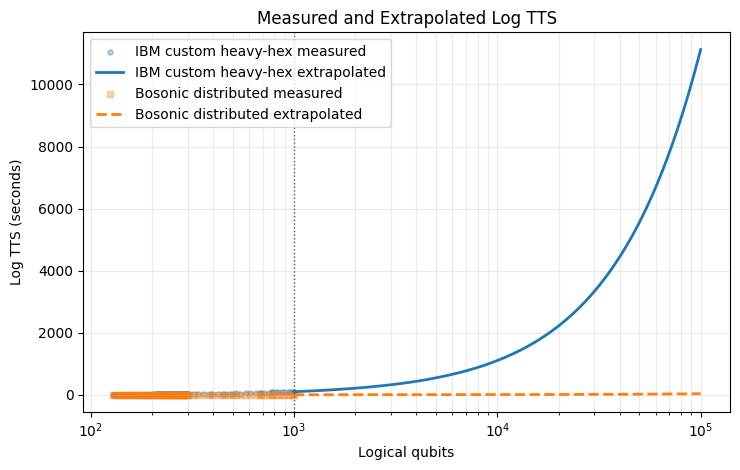

In [1027]:
fig, ax = plot_measured_and_extrapolated_metric(
    benchmark_tts_by_series,
    extended_extrapolation_by_series,
    'log_tts',
    'Log TTS (seconds)',
    yscale='linear',
    title='Measured and Extrapolated Log TTS',
    cutoff_n=EXTENDED_SCALING_CFG['MAX_QUBITS'],
    **benchmark_plot_opts,
)
plt.show()


## Interpreting Results


These projections highlight a key scaling challenge for monolithic approaches.

At small sizes, monolithic circuits with fast native gates can outperform distributed ones by far. As size grows, routing overhead begins to dominate. We explored this on a superconducting system, where distant qubits are entangled via SWAP chains, but routing is still an issue in architectures where qubits can be physically moved around the QPU (shuttling ions with QCCD, shuttling neutral atoms with AOMs, shuttling spin qubits from cell to cell across a silicon chip).

Distributed systems introduce their own challenges (for example remote entanglement and coordination overhead), but they provide a practical path to larger effective system sizes.

## Relaxing Assumptions

We assumed that gates are executed sequentially, but in many architectures multiple gates on different qubits can happen simultaneously. For the fake IBM backend, we can actually use Qiskit to inspect the gate timing of a transpiled circuit:

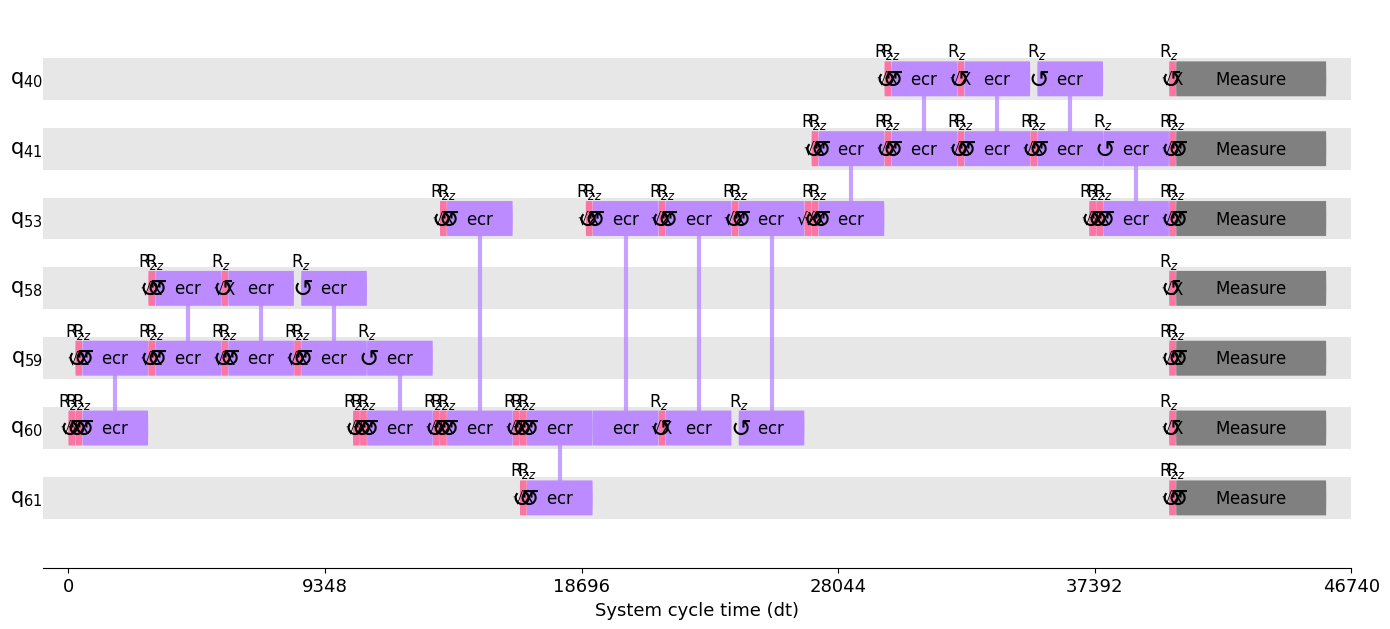

In [1037]:
# compilation is non-deterministic – run this cell a few times to see the changes
qiskit.visualization.timeline.draw(
    qiskit.transpile(ghz_circuit(7), backend=FAKE_IBM_BACKEND, optimization_level=3),
    target=FAKE_IBM_BACKEND.target,
    show_idle=False,
)

Since transpilation is non-deterministic, transpiling the same circuit multiple times results in a distribution of outcomes. (How would you modify the earlier experiments to use this information?)

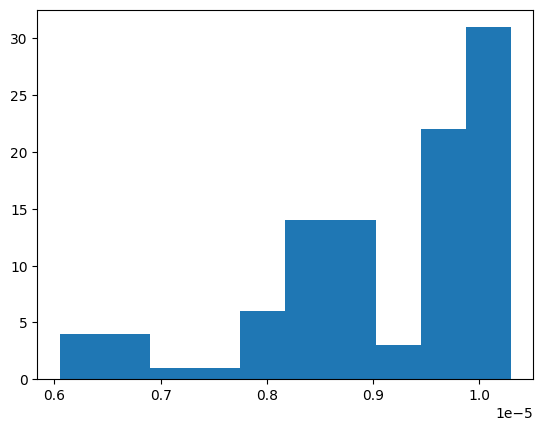

In [1038]:
def _duration(circuit):
    transpiled =  qiskit.transpile(
        circuit, backend=FAKE_IBM_BACKEND, optimization_level=3
    )
    return transpiled.estimate_duration(target=FAKE_IBM_BACKEND.target)

_circuit = ghz_circuit(7)
plt.hist(pd.DataFrame({'duration': [_duration(_circuit) for _ in range(100)]}))
plt.show()

## Testing the Model

We can compare the simple model of execution time to the built-in `estimate_duration` method (which includes the parallel gate execution we saw in the previous section).

In [1039]:
tts_comp_df = tts_df.loc[tts_df['backend'] == 'IBM', ['n', 't_shot', 'circuit']]

# use `estimate_duration` to get the predicted execution time of each circuit
tts_comp_df['t_shot_backend'] = tts_comp_df['circuit'].apply(
    lambda qc: qc.estimate_duration(target=FAKE_IBM_BACKEND.target)
)

# remove device overhead (not measured in estimate_duration)
_overhead = device_df[device_df['backend'] == 'IBM'].iloc[0]['t_overhead']
tts_comp_df['t_shot'] = tts_comp_df['t_shot'] - _overhead

# compute ratio between our predicted time and the built-in prediction
tts_comp_df['ratio'] = tts_comp_df['t_shot'] / tts_comp_df['t_shot_backend']


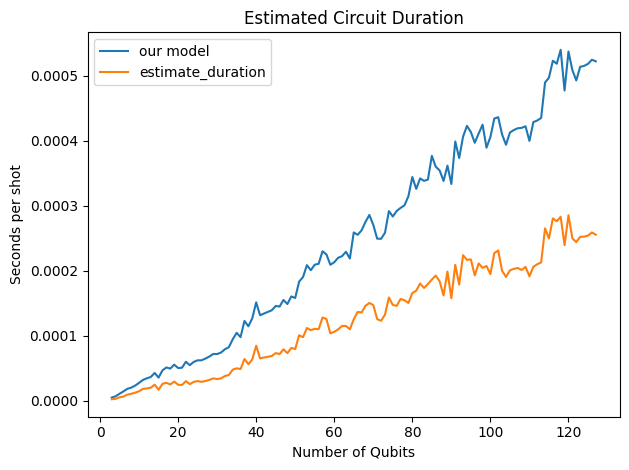

In [1040]:
def backend_check(df):
    plt.plot(df["n"], df["t_shot"], label="our model")
    plt.plot(df["n"], df["t_shot_backend"], label="estimate_duration")

    plt.xlabel("Number of Qubits")
    plt.ylabel("Seconds per shot")
    plt.title("Estimated Circuit Duration")
    plt.legend()

    plt.tight_layout()
    return plt

backend_check(tts_comp_df).show()

Our simple model (where we assume each gate is executed sequentially) is slower than the backend's built-in estimate, but the important feature (which drove our qualitative results) is that shot time is approximately linear in the number of qubits. The ratio by which we overstimate execution time is remarkably stable at around 2.3.

## Other Dimensions

However, we neglected one of the biggest advantages that distributed systems have: their ability to run computations in parallel on different modules/QPUs. One can also use this ability to run computations in parallel to run different parts of a circuit at the same time! This is one of the biggest advantages of distributed quantum computing but implementation is not as trivial as one may think. Refer back to the slides to learn more!

---

# Try it Yourself!

You may have noticed that the scaling behaviour for our circuits had the same shape across different metrics. This was due to our choice of using GHZ circuits. As we scaled up we added two exactly one CNOT which made all of our scaling trivial. Below is a sandbox where you can design your own circuit and use all of the tools we have defined to explore scaling using your own circuit!

Start in the cell below by defining your circuit! The only requirement is to add some dependency on the number of qubits $n$ so that your circuit has some sort of scaling and is compatible with all of our functions! This is left as an excercise for your own time or if you get through the notebook earlier than others!

## Build Your Own Experiment

In this section, you can swap in your own circuit family and reuse the same compilation, metric, TTS, and extrapolation tools from the rest of the notebook.

The only requirement is that `circuit_fn(n)` returns a measured Qiskit circuit with `n` qubits.

In [1050]:
YOUR_CFG = {
    'N_LIST': range(9, 46, 9),
    'N_EXTRAP': np.logspace(1, 5, 24).astype(int),
    'QUBITS_PER_TRAP': 20,
    'PLOT_METRICS':  ['two_qubit_count', 'single_qubit_count', 'total_ops']
}

# Default is a Shor 9 Qubit error correcting circuit
def circuit_fn(n: int):
    if n % 9 != 0 or n < 9:
        raise ValueError('Use n as a positive multiple of 9 (e.g., 9, 18, 27, ...).')
    _qc = qiskit.QuantumCircuit(n, n)
    n_blocks = n // 9
    for b in range(n_blocks):
        o = 9 * b
        _qc.cx(o + 0, o + 3)
        _qc.cx(o + 0, o + 6)
        _qc.h(o + 0)
        _qc.h(o + 3)
        _qc.h(o + 6)
        for r in [o + 0, o + 3, o + 6]:
            _qc.cx(r, r + 1)
            _qc.cx(r, r + 2)
    _qc.measure(range(n), range(n))
    return _qc

Now compile your circuit family in the same two ways we used for GHZ circuits: once for the monolithic IBM backend and once for the distributed Bosonic backend.

In [1051]:
if mo.running_in_notebook():
    _iter = mo.status.progress_bar(
        YOUR_CFG['N_LIST'],
        title='Compiling your circuits',
        subtitle='Monolithic IBM backend',
    )
else:
    _iter = YOUR_CFG['N_LIST']

your_ibm = [scale_ibm(n, optimization_level=3, constructor=circuit_fn) for n in _iter]

In [1052]:
if mo.running_in_notebook():
    _iter = mo.status.progress_bar(
        YOUR_CFG['N_LIST'],
        title='Compiling your circuits',
        subtitle='Distributed Bosonic backend',
    )
else:
    _iter = YOUR_CFG['N_LIST']

_distributor = bosonic_sdk.BosonicDistributor()
your_bosonic = [
    scale_bosonic(n, constructor=circuit_fn, distributor=_distributor)
    for n in _iter
]


In [1053]:
your_circuit_df = pd.DataFrame(your_ibm + your_bosonic)


Next, collect the same circuit metrics and TTS estimates used earlier in the notebook.

In [1054]:
_your_metrics = lambda g: pd.Series(circuit_metrics(g['circuit']))
your_scaling_df = add_remote_link_terms(
    your_circuit_df.join(your_circuit_df.apply(_your_metrics, axis=1))
)
your_tts_df = your_scaling_df.join(
    your_scaling_df.merge(device_df, on='backend').apply(tts_data_series, axis=1)
)


Choose the metrics you want to inspect by editing `YOUR_METRICS_TO_PLOT` in the first cell of this section.

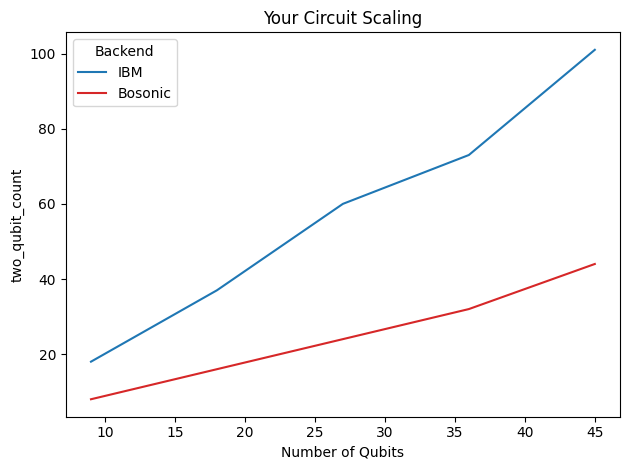

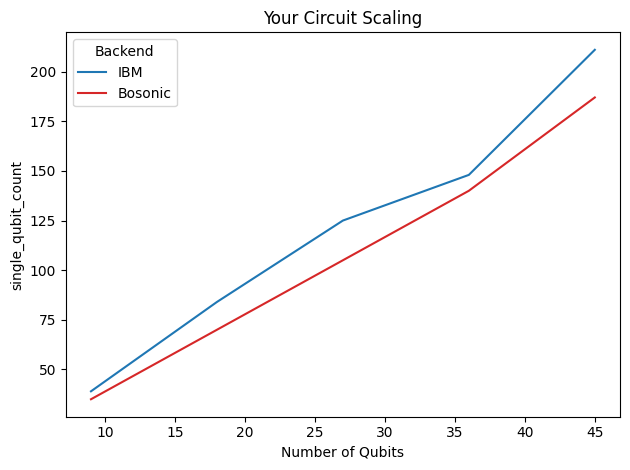

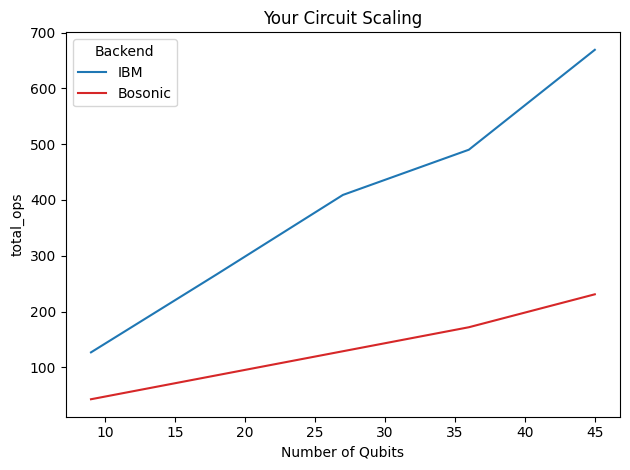

In [1055]:
for _metric in YOUR_CFG['PLOT_METRICS']:
    plot_scaling_metric(
        your_tts_df,
        _metric,
        title='Your Circuit Scaling',
    )

As we 

Finally, extrapolate your measured gate counts and reuse the same TTS model to estimate how the circuit family might behave at larger sizes.

In [1056]:
your_pred_df = gate_count_prediction(your_scaling_df, YOUR_CFG['N_EXTRAP'])
your_extrapolation_df = your_pred_df.join(
    your_pred_df.merge(device_df, on='backend').apply(tts_data_series, axis=1)
)

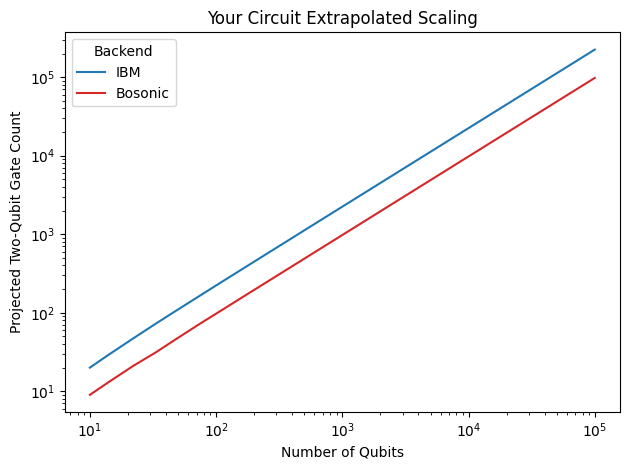

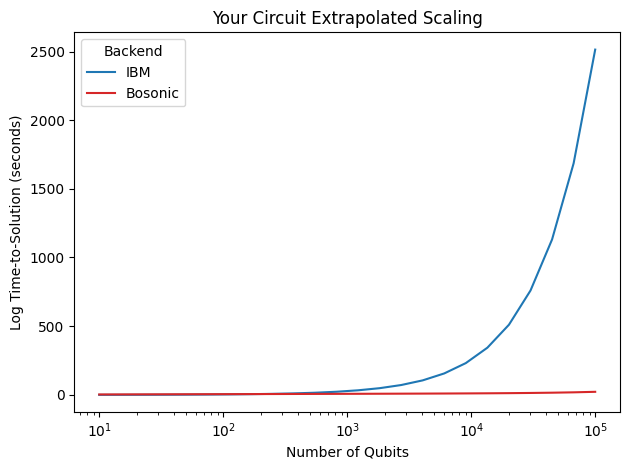

In [1057]:
plot_scaling_metric(
    your_extrapolation_df,
    'two_qubit_count',
    title='Your Circuit Extrapolated Scaling',
    xscale='log',
    yscale='log',
    ylabel='Projected Two-Qubit Gate Count',
)

plot_scaling_metric(
    your_extrapolation_df,
    'log_tts',
    title='Your Circuit Extrapolated Scaling',
    xscale='log',
    yscale='linear',
    ylabel='Log Time-to-Solution (seconds)',
)